# MIC-CC — Modelo Financiero de Riesgo Cambiario · Fase 4

**Monitor de Inteligencia Comercial Colombia–Canadá** · ODEM — Universidad EAN · Manuela Alcalá

Mide cuánto del margen de exportación de los diez productos con mayor Ventaja Comparativa Revelada
hacia Canadá sobrevive a un choque cambiario realista del COP/CAD, y qué puede hacer un exportador
PYME al respecto antes de que ocurra.

---

### Cómo leer este cuaderno

Este cuaderno **orquesta; no calcula**. Cada fórmula vive una sola vez en el paquete
[`src/mic_cc/`](../src/mic_cc/) y está cubierta por [`tests/test_modelo.py`](../tests/test_modelo.py),
ejecutable con `pytest`. Aquí solo se cargan datos, se llaman esas funciones y se guardan resultados.

Es la **versión consolidada**: unifica el modelo original de la Fase 4, las correcciones de la
auditoría cuantitativa de julio de 2026 y la refactorización a paquete. Las tres versiones previas
del cuaderno están en el historial de git; el árbol de trabajo tiene una sola.

### Regla de lectura de los resultados

Cada parámetro del modelo lleva un **grado de evidencia**: **A** dato duro de fuente primaria,
**B** dato gremial cuantificado por inferencia, **C** supuesto de trabajo — *que no es evidencia*.
Catorce de los veinticuatro parámetros inventariados son grado C, y el inventario incluye a
propósito los supuestos de modelado — `pass_through_flete`, `perfil_exportador`, el payload por
clase de densidad — que mueven el resultado tanto como cualquier dato. Por eso los resultados por
producto se reportan como **banda**, nunca como punto, y el semáforo de riesgo solo asigna Verde si
el producto resiste en el extremo desfavorable de su propia banda.

> Ninguna conclusión que dependa de un parámetro grado C debe presentarse como hallazgo.
> El inventario completo está en [`docs/04_datos_pendientes.md`](../docs/04_datos_pendientes.md).

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# El nucleo analitico no depende de matplotlib. Se importa de forma opcional para
# que el cuaderno siga siendo ejecutable donde la extension nativa este bloqueada
# por politica del sistema, en vez de abortar el modelo entero por no dibujar.
try:
    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    _f = plt.figure(); plt.close(_f)      # el backend se resuelve tarde: hay que probarlo
    GRAFICOS, MOTIVO_SIN_GRAFICOS = True, ''
except Exception as _e:                                        # pragma: no cover
    GRAFICOS, MOTIVO_SIN_GRAFICOS = False, f'{type(_e).__name__}: {_e}'

# Raiz del repositorio: el cuaderno corre igual desde notebooks/ o desde la raiz.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'mic_cc').is_dir())
sys.path.insert(0, str(RAIZ / 'src'))
import mic_cc
from mic_cc import config, datos, modelo, riesgo

DATA = RAIZ / 'data' / 'raw'
PROC = RAIZ / 'data' / 'processed'
OUT = RAIZ / 'outputs'
for _d in (PROC, OUT / 'tables', OUT / 'figures'):
    _d.mkdir(parents=True, exist_ok=True)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
warnings.filterwarnings('ignore', category=FutureWarning)

P = config.PARAMS
print(f'mic_cc v{mic_cc.__version__}  |  {len(P)} parametros  |  '
      f'perfil del exportador: {P["perfil_exportador"]}')
print(f'raiz del repositorio: {RAIZ}')
if not GRAFICOS:
    print(f'\nAVISO: matplotlib no disponible ({MOTIVO_SIN_GRAFICOS}).')
    print('       El modelo y todas las tablas se calculan igual; solo se omiten las figuras.')

ev = config.resumen_evidencia()
display(ev.grado.value_counts().sort_index().rename('parametros').to_frame().T)
print('Grado C = supuesto de trabajo, no evidencia. Toda conclusion que dependa de uno '
      'se reporta como banda, nunca como punto.')

mic_cc v3.0.0  |  33 parametros  |  perfil del exportador: productor
raiz del repositorio: C:\Users\alcal\proyectos personales\mic-cc finanzas


grado,A,B,C
parametros,5,5,14


Grado C = supuesto de trabajo, no evidencia. Toda conclusion que dependa de uno se reporta como banda, nunca como punto.


## 1 · Serie COP/CAD

El COP/CAD no se cotiza directamente en ningún mercado: se construye como **tasa cruzada** a partir
de la TRM oficial (COP/USD, Banco de la República) y del USD/CAD (Bank of Canada).

$$\text{COP/CAD} = \frac{\text{COP/USD}}{\text{CAD/USD}}$$

**Alineación temporal.** La TRM vigente el día *D* se calcula con las operaciones del día hábil
*D−1*, mientras que la cotización del Bank of Canada del día *D* refleja el mercado de *D*. Cruzarlas
por fecha nominal mezcla dos días de mercado distintos e infla la varianza con ruido de
emparejamiento. La celda mide ese ruido explícitamente.

El modelo descarga las dos series en vivo y **cae automáticamente a los archivos de `data/raw/`
si no hay red**. La procedencia efectiva de cada insumo queda impresa abajo, para que sea trazable.

In [2]:
fx, origen = datos.cargar_fx(P, str(DATA))

# Contrafactual sin alinear: mide cuanta volatilidad es ruido de emparejamiento.
try:
    fx_sin = datos.construir_copcad(datos.descargar_trm(P['fx_inicio'], P['fx_fin']),
                                    datos.descargar_usdcad(P['fx_inicio'], P['fx_fin']),
                                    alinear_rezago=False)
except Exception:                                              # pragma: no cover
    fx_sin = datos.construir_copcad(datos.cargar_trm_local(DATA / 'TRM_COP_USD_2020_2024.xlsx'),
                                    datos.cargar_usdcad_local(DATA / 'USDCAD_2020_2024.xlsx'),
                                    alinear_rezago=False)

r = fx['retorno_log'].dropna()
fx_base = fx['COP_CAD'].rolling(P['ventana_base_dias']).mean().dropna().iloc[-1]
fx_spot = fx['COP_CAD'].iloc[-1]
trm_hoy = fx['TRM_COP_USD'].iloc[-1]
vol = riesgo.volatilidad_anualizada(r, P['dias_habiles_anio'])
vol_sin = riesgo.volatilidad_anualizada(fx_sin['retorno_log'], P['dias_habiles_anio'])

fx.to_excel(PROC / 'fx_copcad.xlsx', index=False)

print(f'TRM     : {origen["trm"]}')
print(f'USD/CAD : {origen["usdcad"]}')
print(f'\n{len(fx):,} observaciones diarias  |  {fx.fecha.min().date()} -> {fx.fecha.max().date()}')
print(f'  spot {fx_spot:,.2f}   base MM{P["ventana_base_dias"]} {fx_base:,.2f}   TRM {trm_hoy:,.2f}')
print(f'\nAlineacion TRM(D) <-> BoC(D-1):')
print(f'  volatilidad anualizada alineada  {vol:.4%}')
print(f'  sin alinear                      {vol_sin:.4%}   '
      f'(+{(vol_sin - vol) * 1e4:.0f} pb que son ruido de emparejamiento, no riesgo)')
display(fx.tail(3).round(4))

TRM     : Datos Abiertos (BanRep), en vivo
USD/CAD : Bank of Canada Valet, en vivo

2,336 observaciones diarias  |  2014-01-03 -> 2026-09-11
  spot 2,243.52   base MM90 2,481.14   TRM 3,101.00

Alineacion TRM(D) <-> BoC(D-1):
  volatilidad anualizada alineada  13.9404%
  sin alinear                      16.5536%   (+261 pb que son ruido de emparejamiento, no riesgo)


C:\Users\alcal\AppData\Local\Temp\ipykernel_720\941024377.py:30: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(fx.tail(3).round(4))


,fecha,TRM_COP_USD,USDCAD,COP_CAD,retorno_log
2333,2026-09-09,3116.47,1.3784,2260.9330,-0.0076
2334,2026-09-10,3099.48,1.3798,2246.3256,-0.0065
2335,2026-09-11,3101.00,1.3822,2243.5248,-0.0012


## 2 · Riesgo cambiario: VaR, Expected Shortfall y calibración

Cuatro decisiones metodológicas separan este módulo de la primera versión del modelo:

1. **El VaR multihorizonte usa el cuantil empírico**, no el escalado √T. Escalar un *cuantil* por
   √T es exacto solo bajo retornos i.i.d. de distribución estable — el caso canónico es la normal —
   y Jarque-Bera rechaza la normalidad de esta misma serie. El escalado se conserva únicamente como
   referencia, con su sesgo medido.
2. **El N efectivo se reporta.** Las ventanas de *T* días se solapan; la muestra independiente real
   es `len/T`, no `len`.
3. **El backtest de Kupiec es fuera de muestra.** El VaR pronosticado para *t* usa solo información
   anterior a *t*. Un backtest in-sample arroja ~5% de violaciones por construcción y no valida nada.
4. **Los escenarios son cuantiles empíricos a 90 días de la propia serie**, no un ±10%/−15%
   arbitrario. Noventa días es el horizonte de cobro típico de una exportación a Canadá.

In [3]:
v95 = riesgo.var_historico(r, P['nivel_confianza'])
v99 = riesgo.var_historico(r, 0.99)
es95 = riesgo.expected_shortfall(r, P['nivel_confianza'])
jb = riesgo.jarque_bera(r)
oos = riesgo.backtest_var_oos(fx['retorno_log'], P['ventana_var_movil'], P['nivel_confianza'])
mh = riesgo.var_multihorizonte(r, fx['COP_CAD'], P['horizontes_cobro'], P['nivel_confianza'])

print(f'Volatilidad anualizada {vol:.4%}  |  VaR95 1d {v95:.4%}  |  VaR99 1d {v99:.4%}  '
      f'|  ES95 1d {es95:.4%}')
print(f'\nJarque-Bera {jb["jb"]:,.1f} (p = {jb["p_value"]:.2e})  ->  normalidad '
      f'{"NO rechazada" if jb["normal"] else "RECHAZADA"}')
print(f'  asimetria {jb["asimetria"]:+.3f}  |  curtosis en exceso {jb["curtosis_exceso"]:+.3f}')
print(f'  => {"admisible" if jb["normal"] else "NO admisible"} escalar cuantiles por sqrt(T). '
      f'Se usa el cuantil empirico.')
print(f'\nKupiec fuera de muestra: {oos["violaciones"]}/{oos["n_obs"]} = '
      f'{oos["tasa_observada"]:.2%} (esperado {1 - P["nivel_confianza"]:.2%})  |  '
      f'p = {oos["p_value"]:.4f}  ->  '
      f'{"calibracion aceptable" if oos["bien_calibrado"] else "SE RECHAZA la buena calibracion"}')
display(mh.round(4))

acum90 = np.log(fx['COP_CAD'] / fx['COP_CAD'].shift(P['ventana_base_dias'])).dropna()
ESC = {'Pesimista': riesgo.nivel_desde_retorno_log(fx_base, np.percentile(acum90, 5)),
       'Base': fx_base,
       'Optimista': riesgo.nivel_desde_retorno_log(fx_base, np.percentile(acum90, 95))}
var90 = mh.loc[mh.horizonte_dias == 90, 'var_empirico'].iloc[0]
fx_var90 = riesgo.nivel_desde_retorno_log(fx_base, var90)

print('\nEscenarios cambiarios (cuantiles empiricos a 90 dias de la propia serie):')
for k in ('Pesimista', 'Base', 'Optimista'):
    print(f'  {k:10s} {ESC[k]:9,.2f}   ({(ESC[k] / fx_base - 1) * 100:+6.2f}% vs. base)')
print(f'  {"VaR90":10s} {fx_var90:9,.2f}   ({var90 * 100:+6.2f}%)   <- umbral del semaforo')
print(f'  {"Spot":10s} {fx_spot:9,.2f}   ({(fx_spot / fx_base - 1) * 100:+6.2f}%)')

Volatilidad anualizada 13.9404%  |  VaR95 1d -1.3042%  |  VaR99 1d -2.3216%  |  ES95 1d -1.9261%

Jarque-Bera 996.6 (p = 3.93e-217)  ->  normalidad RECHAZADA
  asimetria +0.342  |  curtosis en exceso +3.126
  => NO admisible escalar cuantiles por sqrt(T). Se usa el cuantil empirico.

Kupiec fuera de muestra: 124/2083 = 5.95% (esperado 5.00%)  |  p = 0.0524  ->  calibracion aceptable


,horizonte_dias,var_empirico,var_sqrt_t,peor_observado,n_ventanas_solapadas,n_efectivo_independiente,sesgo_sqrt_t_pct
0,30,-0.0665,-0.0714,-0.1927,2306,76.9,7.3651
1,60,-0.0950,-0.1010,-0.2037,2276,37.9,6.3615
2,90,-0.1164,-0.1237,-0.2061,2246,25.0,6.3011



Escenarios cambiarios (cuantiles empiricos a 90 dias de la propia serie):
  Pesimista   2,208.52   (-10.99% vs. base)
  Base        2,481.14   ( +0.00% vs. base)
  Optimista   2,819.30   (+13.63% vs. base)
  VaR90       2,208.52   (-11.64%)   <- umbral del semaforo
  Spot        2,243.52   ( -9.58%)


## 3 · Productos, precios y estructura de costos

Los diez productos vienen de la fase comercial (identificación por Ventaja Comparativa Revelada).
Sobre los datos crudos se aplican dos correcciones verificadas contra fuente primaria, registradas
en `config.OVERRIDES` y exportadas como `tabla_00`: el precio del café y el USD/CAD.

**El cambio de fondo es el ratio de costo.** El modelo original aplicaba un factor único de 0,60 a
los diez productos. Al ser uniforme, ese factor vuelve la ecuación
`margen% = 1 − factor − accesorios` **idéntica para los diez**, de modo que cualquier ranking de
rentabilidad por producto era un artefacto del precio por kilogramo, no evidencia. Aquí cada
producto tiene una **banda** `[ratio_min, ratio_base, ratio_max]` con su grado de evidencia.

Ninguno de los diez ratios llega a grado A bajo el perfil **productor**, que es el que el modelo usa
por defecto: cuatro son B y seis son C. El único ratio de grado A del proyecto es el del café bajo
el perfil **comercializador**, porque solo ahí el costo es un precio de compra publicado. Conviene
tener presente esa distinción antes de leer cualquier cifra por producto.

In [4]:
prod = pd.read_excel(DATA / 'tabla_B4_precios_referencia.xlsx')
prod.columns = ['numero', 'producto', 'codigo_hs', 'precio_usd', 'unidad', 'tc_usd_cad',
                'precio_cad', 'fuente', 'fecha_consulta']
prod['precio_usd_original'] = prod['precio_usd']
prod['precio_cad_original'] = prod['precio_cad']
for _, o in config.OVERRIDES.iterrows():
    if o.campo == 'precio_usd':
        prod.loc[prod.codigo_hs == o.codigo_hs, 'precio_usd'] = o.valor_corregido
    elif o.campo == 'tipo_cambio_usd_cad':
        prod['tc_usd_cad'] = o.valor_corregido
prod['precio_cad'] = prod['precio_usd'] * prod['tc_usd_cad']

est = pd.read_excel(DATA / 'tabla_B9_estructura_costos.xlsx')
est['pct_importado'] = est['pct_importado'] / 100
prod = (prod.merge(est[['codigo_hs', 'pct_importado']], on='codigo_hs', validate='1:1')
            .merge(config.TRANSPORTE, on='codigo_hs', validate='1:1')
            .merge(config.COSTOS_SECTOR.drop(columns='producto'), on='codigo_hs', validate='1:1'))
assert len(prod) == 10, 'Se esperaban exactamente 10 productos del Top 10'

# El ratio efectivo depende del perfil: producir no cuesta lo mismo que comprar para revender.
usar_com = P['perfil_exportador'] == 'comercializador'
prod['ratio_efectivo'] = prod['ratio_comercializador'] if usar_com else prod['ratio_base']
for _col, _ratio in [('costo_base', 'ratio_efectivo'), ('costo_min', 'ratio_min'),
                     ('costo_max', 'ratio_max')]:
    prod[_col] = prod['precio_cad'] * fx_base * prod[_ratio]

print(f'Incoterm declarado en la fuente: {prod["unidad"].unique()[0]}')
print(f'Perfil del exportador: {P["perfil_exportador"]}   |   '
      f'pass-through del flete: {P["pass_through_flete"]:.0%}\n')
display(prod[['producto', 'codigo_hs', 'precio_cad_original', 'precio_cad', 'pct_importado',
              'modo_transporte', 'ratio_min', 'ratio_efectivo', 'ratio_max', 'grado']].round(3))
print(f'Grados de los ratios de costo: {prod.grado.value_counts().sort_index().to_dict()}   '
      f'(el modelo original usaba 0.60 para los diez, sin fuente)')

Incoterm declarado en la fuente: Kilogramo (FOB)
Perfil del exportador: productor   |   pass-through del flete: 100%



,producto,codigo_hs,precio_cad_original,precio_cad,pct_importado,modo_transporte,ratio_min,ratio_efectivo,ratio_max,grado
0,Café sin tostar,0901.11.90.00,4.256,11.009,0.25,maritimo,0.50,0.62,0.72,B
1,Carbón bituminoso,2701.12.00.00,0.117,0.124,0.15,granel,0.70,0.85,0.95,C
2,Frutas tropicales (guayaba/mango),0804.50.00.00,1.596,1.690,0.30,maritimo,0.65,0.75,0.85,C
3,Flores frescas otras (pompones/hortensias),0603.19.00.00,3.325,3.521,0.30,aereo,0.80,0.87,0.93,B
4,Medicamentos corticosteroides,3004.32.00.00,37.240,39.432,0.65,maritimo,0.40,0.55,0.70,C
5,Medias/calcetines fibra sintética,6115.96.00.00,9.044,9.576,0.55,maritimo,0.65,0.74,0.82,C
6,Accesorios tubería hierro/acero,7307.92.00.00,2.793,2.957,0.40,maritimo,0.70,0.79,0.88,C
7,Filetes de trucha congelados,0304.82.00.00,7.315,7.746,0.55,maritimo,0.70,0.79,0.87,B
8,Nueces y semillas preparadas,2008.19.00.00,5.719,6.056,0.55,maritimo,0.75,0.83,0.90,C
9,Rosas frescas cortadas,0603.11.00.00,3.724,3.943,0.30,aereo,0.80,0.87,0.93,B


Grados de los ratios de costo: {'B': 4, 'C': 6}   (el modelo original usaba 0.60 para los diez, sin fuente)


In [5]:
# Anclaje del cafe con fuente primaria de la FNC, y contraste de los dos perfiles.
HS_CAFE = '0901.11.90.00'
fnc = modelo.precio_fob_cafe_desde_fnc(2_210_000, trm_hoy, P)
fob_cafe_cop = prod.loc[prod.codigo_hs == HS_CAFE, 'precio_usd'].iloc[0] * trm_hoy
ratio_com = fnc['precio_interno_cop_kg'] / fob_cafe_cop

print('CAFE - unico ratio de grado A del proyecto, y solo bajo el perfil comercializador')
print(f'  precio interno de compra        2,210,000 COP / carga de {P["kg_cps_por_carga"]} kg cps')
print(f'  rendimiento                     {P["factor_rendimiento"]} kg cps -> '
      f'{P["kg_excelso_por_saco"]} kg excelso')
print(f'  equivale a                      {fnc["kg_excelso_por_carga"]:.2f} kg de excelso exportable')
print(f'  precio interno                  {fnc["precio_interno_cop_kg"]:,.0f} COP/kg  '
      f'({fnc["precio_interno_usd_kg"]:.3f} USD/kg)')
print(f'  precio FOB de exportacion       {fob_cafe_cop:,.0f} COP/kg  (NY 324.55 USc/lb + prima)')
print(f'\n  ratio costo/FOB si COMERCIALIZA {ratio_com:.3f}   <- grado A, dato duro')
print(f'  ratio asumido si PRODUCE        '
      f'{prod.loc[prod.codigo_hs == HS_CAFE, "ratio_base"].iloc[0]:.3f}   <- grado B, inferido')
print('\nEl modelo original asumia 0.60 sin distinguir los dos casos. La diferencia entre producir')
print('y comercializar cambia el margen del cafe por un factor cercano a 2: es una decision de')
print('modelado, no un detalle, y por eso es un parametro explicito del modelo.')
print('\nEse ratio no es una constante: se RECALCULA con la TRM vigente. El precio interno de la')
print('FNC esta fijado en COP y el FOB se cotiza en USD, asi que un peso mas fuerte lo comprime.')
print(f'A la TRM de la auditoria (3,219, jul-2026) daba 0.943; a la TRM de hoy '
      f'({trm_hoy:,.0f}) da {ratio_com:.3f}.')

CAFE - unico ratio de grado A del proyecto, y solo bajo el perfil comercializador
  precio interno de compra        2,210,000 COP / carga de 125 kg cps
  rendimiento                     94 kg cps -> 70 kg excelso
  equivale a                      93.09 kg de excelso exportable
  precio interno                  23,742 COP/kg  (7.656 USD/kg)
  precio FOB de exportacion       24,241 COP/kg  (NY 324.55 USc/lb + prima)

  ratio costo/FOB si COMERCIALIZA 0.979   <- grado A, dato duro
  ratio asumido si PRODUCE        0.620   <- grado B, inferido

El modelo original asumia 0.60 sin distinguir los dos casos. La diferencia entre producir
y comercializar cambia el margen del cafe por un factor cercano a 2: es una decision de
modelado, no un detalle, y por eso es un parametro explicito del modelo.

Ese ratio no es una constante: se RECALCULA con la TRM vigente. El precio interno de la
FNC esta fijado en COP y el FOB se cotiza en USD, asi que un peso mas fuerte lo comprime.
A la TRM de la auditori

### 3.1 Logística: el modo de transporte real de cada producto

El modelo original aplicaba tarifa de **contenedor marítimo desde Cartagena** a los diez productos.
Dos casos lo contradicen de raíz: las flores, de las que ~92% salen **por aire** desde El Dorado, y
el carbón bituminoso, que es **granel** y no viaja en contenedor. Cobrar tarifa de contenedor a un
commodity a granel es el origen mecánico del breakeven imposible que el carbón mostraba antes.

Además, el payload útil depende de la densidad: un contenedor de 20 pies tiene ~33 m³ y ~28 t de
capacidad, pero la carga ligera "cuba" antes de "pesar", así que su costo por kilogramo es mucho
mayor. La carga refrigerada paga recargo reefer.

In [6]:
fl = pd.read_excel(DATA / 'costos_logisticos_rutas.xlsx')
fl['tarifa_usd'] = fl['tarifa_usd_teu'].apply(
    lambda v: float(str(v).replace('$', '').replace(' ', '').replace('.', '').replace(',', '.')))
RUTAS = {'Cartagena CO - Montreal CA': 'CTG-Montreal',
         'Cartagena CO - Vancouver CA': 'CTG-Vancouver'}
fl = fl[fl.ruta.isin(RUTAS) & (fl.tipo_contenedor == '20 pies')].copy()
fl['ruta_modelo'] = fl.ruta.map(RUTAS)
tarifa = fl.groupby('ruta_modelo')['tarifa_usd'].mean().to_dict()

fletes = pd.DataFrame([
    dict(codigo_hs=x.codigo_hs, producto=x['producto'], ruta=ruta, modo=x.modo_transporte,
         clase_densidad=x.clase_densidad, requiere_frio=x.requiere_frio,
         costo_logistico_cop_kg=(c := modelo.costo_logistico_cop_kg(
             x.modo_transporte, x.clase_densidad, x.requiere_frio, ruta,
             tarifa[ruta], trm_hoy, P))[0], detalle=c[1])
    for _, x in prod.iterrows() for ruta in tarifa])


def flete_de(hs, ruta):
    m = (fletes.codigo_hs == hs) & (fletes.ruta == ruta)
    return fletes.loc[m, 'costo_logistico_cop_kg'].iloc[0]


print('Tarifas de contenedor 20 pies:  '
      + '  |  '.join(f'{k} {v:,.0f} USD' for k, v in tarifa.items()))
print(f'TRM usada para convertir fletes a COP: {trm_hoy:,.2f}\n')
display(fletes.pivot_table(index=['producto', 'modo'], columns='ruta',
                           values='costo_logistico_cop_kg').round(0))

Tarifas de contenedor 20 pies:  CTG-Montreal 1,046 USD  |  CTG-Vancouver 5,281 USD
TRM usada para convertir fletes a COP: 3,101.00



,ruta,CTG-Montreal,CTG-Vancouver
producto,modo,,
Accesorios tubería hierro/acero,maritimo,162.0,819.0
Café sin tostar,maritimo,162.0,819.0
Carbón bituminoso,granel,47.0,68.0
Filetes de trucha congelados,maritimo,432.0,2184.0
Flores frescas otras (pompones/hortensias),aereo,8683.0,8683.0
Frutas tropicales (guayaba/mango),maritimo,432.0,2184.0
Medias/calcetines fibra sintética,maritimo,463.0,2339.0
Medicamentos corticosteroides,maritimo,270.0,1365.0
Nueces y semillas preparadas,maritimo,463.0,2339.0


## 4 · Verificación manual preliminar (`tabla_B5`)

La Tarea 5 del Bloque A pide una tabla de 30 filas (10 productos × 3 escenarios) construida a mano,
**antes** del modelo, como control de que la lógica del margen es la correcta. Se reproduce aquí de
forma programática para que sea auditable y no dependa de una hoja de cálculo manual perdida.

Es deliberadamente **más simple** que el modelo: usa el spot como base, escenarios ±10%/−15%
arbitrarios, factor de costo 0,60 uniforme, y no incluye logística, accesorios ni cobertura natural.
Sus cifras **no deben coincidir** con las de `tabla_05`; lo que debe coincidir es la lógica.

El control que importa: **el costo en pesos se calcula una sola vez, con el tipo de cambio base, y
se mantiene fijo en los tres escenarios.** Si se recalculara con el tipo de cambio de cada escenario,
el margen saldría idéntico en los tres y la tabla no mostraría ninguna sensibilidad cambiaria.

In [7]:
ESC_B5 = {'base': 1.00, 'optimista': 1.10, 'pesimista': 0.85}
FACTOR_B5 = 0.60

tabla_B5 = pd.DataFrame([
    dict(numero=int(x.numero), producto=x['producto'], codigo_hs=x.codigo_hs, escenario=esc,
         copcad=(tc := fx_spot * mult), precio_cad=x.precio_cad,
         costo_produccion_cop=(cc := x.precio_cad * fx_spot * FACTOR_B5),
         ingreso_cop=(ing := x.precio_cad * tc),
         margen_bruto_cop=ing - cc, margen_bruto_pct=(ing - cc) / ing * 100)
    for _, x in prod.iterrows() for esc, mult in ESC_B5.items()])

# Verificaciones de calidad que exige la Tarea 5. Todas pueden fallar de verdad.
assert len(tabla_B5) == 30, 'tabla_B5 debe tener exactamente 30 filas'
assert (tabla_B5.groupby('codigo_hs').costo_produccion_cop.nunique() == 1).all(), \
    'el costo en COP debe ser identico en los tres escenarios de cada producto'
assert (tabla_B5.ingreso_cop > 0).all(), 'ningun ingreso puede ser cero'
_p = tabla_B5.pivot_table(index='codigo_hs', columns='escenario', values='margen_bruto_pct')
assert (_p.optimista > _p.base).all() and (_p.base > _p.pesimista).all(), \
    'debe cumplirse optimista > base > pesimista en los 10 productos'

print(f'tabla_B5: {len(tabla_B5)} filas  |  las 4 verificaciones de calidad de la Tarea 5 pasan')
print(f'COP/CAD base (spot) {fx_spot:,.2f}  ->  optimista {fx_spot * 1.10:,.2f}  |  '
      f'pesimista {fx_spot * 0.85:,.2f}\n')
display(_p.join(prod.set_index('codigo_hs')['producto'])
          .set_index('producto')[['pesimista', 'base', 'optimista']].round(1))
print('Con un factor de costo uniforme el margen % es identico para los diez productos. Esa '
      'invariancia\nno es un error de la tabla: es la limitacion que el modelo resuelve en la '
      'seccion siguiente.')

tabla_B5: 30 filas  |  las 4 verificaciones de calidad de la Tarea 5 pasan
COP/CAD base (spot) 2,243.52  ->  optimista 2,467.88  |  pesimista 1,907.00



,pesimista,base,optimista
producto,,,
Filetes de trucha congelados,29.4,40.0,45.5
Rosas frescas cortadas,29.4,40.0,45.5
Flores frescas otras (pompones/hortensias),29.4,40.0,45.5
Frutas tropicales (guayaba/mango),29.4,40.0,45.5
Café sin tostar,29.4,40.0,45.5
Nueces y semillas preparadas,29.4,40.0,45.5
Carbón bituminoso,29.4,40.0,45.5
Medicamentos corticosteroides,29.4,40.0,45.5
Medias/calcetines fibra sintética,29.4,40.0,45.5


Con un factor de costo uniforme el margen % es identico para los diez productos. Esa invariancia
no es un error de la tabla: es la limitacion que el modelo resuelve en la seccion siguiente.


## 5 · Márgenes y punto de equilibrio, con banda de incertidumbre

### Coherencia de incoterm

Los diez precios de `tabla_B4` están cotizados **`Kilogramo (FOB)`**. Bajo FOB el flete
internacional lo paga el comprador; bajo CFR/CIF lo paga el exportador pero se lo factura dentro del
precio. **En los dos casos el flete no destruye margen.** El modelo original lo restaba de un ingreso
FOB que nunca lo incluyó, cobrándolo dos veces — ese es el origen del −348 % del carbón y del margen
negativo de las flores, no la economía de esos productos.

El parámetro `pass_through_flete` hace explícito el supuesto: `1.0` traslado completo al comprador
(defecto), `0.0` el exportador lo absorbe (el supuesto implícito, y nunca declarado, del modelo
original). La sección 10 barre el rango completo.

### Breakeven analítico

El tipo de cambio de equilibrio se resuelve **analíticamente**, incluyendo la cobertura natural — el
costo importado depende del propio FX que se despeja:

$$X^{*} = \frac{C_n + (1-pt)\,L}{P\,(1-a) - C_i / X_b}$$

Con `pt = 1` el flete se cancela y **el breakeven no depende de la ruta**: bajo traslado completo,
elegir Montreal o Vancouver no altera la economía del exportador. Esa invariancia es un resultado
del modelo, no un defecto.

### Semáforo robusto

Cada producto se evalúa en su ratio central **y en los dos extremos de su banda de costos**. El
semáforo solo asigna Verde si el producto resiste en el extremo desfavorable. Reportar un color a
partir de un punto único, cuando el parámetro que lo gobierna es un supuesto grado C, sería falsa
precisión.

In [8]:
filas, be = [], []
ACC, PT = P['costos_accesorios_pct_fob'], P['pass_through_flete']

for _, x in prod.iterrows():
    for ruta in tarifa:
        cl = flete_de(x.codigo_hs, ruta)
        bks = [modelo.breakeven_fx(x.precio_cad, fx_base, cp, x.pct_importado, cl, ACC, PT)
               for cp in (x.costo_base, x.costo_min, x.costo_max)]
        bk_base = bks[0]
        be.append({'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta,
                   'breakeven': bk_base, 'breakeven_min': min(bks), 'breakeven_max': max(bks),
                   'riesgo_puntual': modelo.clasificar_riesgo(bk_base, fx_var90, ESC['Pesimista']),
                   'riesgo_robusto': modelo.semaforo_robusto(bks, fx_var90, ESC['Pesimista']),
                   'grado': x.grado,
                   'colchon_vs_spot_pct': (fx_spot - bk_base) / fx_spot * 100})
        for esc, tc in ESC.items():
            m = modelo.margen(x.precio_cad, tc, fx_base, x.costo_base, x.pct_importado, cl, ACC, PT)
            lo = modelo.margen(x.precio_cad, tc, fx_base, x.costo_max, x.pct_importado, cl, ACC, PT)
            hi = modelo.margen(x.precio_cad, tc, fx_base, x.costo_min, x.pct_importado, cl, ACC, PT)
            u60 = modelo.margen(x.precio_cad, tc, fx_base, x.precio_cad * fx_base * 0.60,
                                x.pct_importado, cl, ACC, PT)
            filas.append({'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta,
                          'escenario': esc, 'COPCAD': tc, 'grado': x.grado,
                          'pct_importado': x.pct_importado, 'ratio_costo': x.ratio_efectivo,
                          'ingreso_cop': m['ingreso_cop'], 'costo_total_cop': m['costo_total_cop'],
                          'costo_importado_cop': m['costo_importado_cop'],
                          'margen_cop': m['margen_cop'], 'margen_pct': m['margen_pct'],
                          'margen_pct_min': lo['margen_pct'], 'margen_pct_max': hi['margen_pct'],
                          'margen_pct_factor_060': u60['margen_pct']})

tabla_margenes, tabla_be = pd.DataFrame(filas), pd.DataFrame(be)
assert len(tabla_margenes) == 60, '10 productos x 2 rutas x 3 escenarios = 60'
assert len(tabla_be) == 20, '10 productos x 2 rutas = 20'

_b = tabla_margenes[(tabla_margenes.escenario == 'Base') & (tabla_margenes.ruta == 'CTG-Montreal')]
print('Margen en escenario Base, ruta Montreal: banda por producto vs. factor unico de 0.60\n')
display(_b[['producto', 'grado', 'ratio_costo', 'margen_pct_min', 'margen_pct',
            'margen_pct_max', 'margen_pct_factor_060']].sort_values('margen_pct').round(1))
print('La columna del factor 0.60 es casi identica para los diez: esa es la prueba de que el '
      'modelo\noriginal no podia discriminar entre productos. La banda si los separa.')

Margen en escenario Base, ruta Montreal: banda por producto vs. factor unico de 0.60



,producto,grado,ratio_costo,margen_pct_min,margen_pct,margen_pct_max,margen_pct_factor_060
19,Flores frescas otras (pompones/hortensias),B,0.9,0.8,3.8,7.3,17.3
55,Rosas frescas cortadas,B,0.9,0.8,4.0,7.7,18.3
7,Carbón bituminoso,C,0.8,-0.4,8.3,21.3,30.0
49,Nueces y semillas preparadas,C,0.8,4.4,11.2,18.9,33.5
43,Filetes de trucha congelados,B,0.8,7.3,15.2,24.0,33.7
37,Accesorios tubería hierro/acero,C,0.8,6.4,15.2,24.0,33.8
13,Frutas tropicales (guayaba/mango),C,0.8,8.6,17.7,26.7,31.3
31,Medias/calcetines fibra sintética,C,0.7,12.3,20.1,28.9,33.8
1,Café sin tostar,B,0.6,22.4,32.3,44.2,34.3
25,Medicamentos corticosteroides,C,0.6,24.4,39.4,54.3,34.4


La columna del factor 0.60 es casi identica para los diez: esa es la prueba de que el modelo
original no podia discriminar entre productos. La banda si los separa.


In [9]:
print('Semaforo puntual vs. robusto (el robusto exige resistir toda la banda de costos):\n')
display(tabla_be[tabla_be.ruta == 'CTG-Montreal'][
    ['producto', 'grado', 'breakeven_min', 'breakeven', 'breakeven_max',
     'riesgo_puntual', 'riesgo_robusto', 'colchon_vs_spot_pct']].sort_values('breakeven').round(1))

print(tabla_be.groupby(['ruta', 'riesgo_robusto']).size().to_string())
_cambia = (tabla_be.riesgo_puntual != tabla_be.riesgo_robusto).sum()
print(f'\nEl semaforo cambia de color al exigir robustez en {_cambia} de {len(tabla_be)} '
      f'combinaciones producto-ruta.')
print(f'Referencias: spot {fx_spot:,.0f}  |  VaR90 {fx_var90:,.0f}  |  '
      f'pesimista {ESC["Pesimista"]:,.0f}')
print('\nEl breakeven es invariante a la ruta por algebra, no por casualidad: con '
      'pass_through_flete = 1.0\nel flete se cancela en la ecuacion de equilibrio.')

Semaforo puntual vs. robusto (el robusto exige resistir toda la banda de costos):



,producto,grado,breakeven_min,breakeven,breakeven_max,riesgo_puntual,riesgo_robusto,colchon_vs_spot_pct
8,Medicamentos corticosteroides,C,507.1,813.0,1240.6,Verde,Verde,63.8
0,Café sin tostar,B,1134.7,1460.4,1751.4,Verde,Verde,34.9
10,Medias/calcetines fibra sintética,C,1235.3,1535.7,1853.3,Verde,Verde,31.5
14,Filetes de trucha congelados,B,1395.6,1727.8,2082.2,Verde,Verde,23.0
4,Frutas tropicales (guayaba/mango),C,1505.2,1809.2,2139.5,Verde,Verde,19.4
12,Accesorios tubería hierro/acero,C,1567.0,1869.7,2209.2,Verde,Rojo,16.7
16,Nueces y semillas preparadas,C,1572.6,1897.0,2233.0,Verde,Rojo,15.4
2,Carbón bituminoso,C,1757.5,2192.8,2496.6,Verde,Rojo,2.3
18,Rosas frescas cortadas,B,1970.8,2209.1,2425.3,Rojo,Rojo,1.5
6,Flores frescas otras (pompones/hortensias),B,1970.8,2209.1,2425.3,Rojo,Rojo,1.5


ruta           riesgo_robusto
CTG-Montreal   Rojo              5
               Verde             5
CTG-Vancouver  Rojo              5
               Verde             5

El semaforo cambia de color al exigir robustez en 6 de 20 combinaciones producto-ruta.
Referencias: spot 2,244  |  VaR90 2,209  |  pesimista 2,209

El breakeven es invariante a la ruta por algebra, no por casualidad: con pass_through_flete = 1.0
el flete se cancela en la ecuacion de equilibrio.


## 6 · Cobertura natural y exposición cambiaria

La porción importada del costo escala con el mismo tipo de cambio que el ingreso; la porción
nacional y el flete no. Eso es un hedge genuino, pero **simétrico**: amortigua la pérdida cuando el
CAD se debilita y recorta la ganancia cuando se fortalece. Presentarlo como un beneficio
incondicional confunde reducción de varianza con aumento de valor.

Se mide contra el contrafactual correcto: **la misma empresa, con el mismo costo total, pero 100 %
nacional**. Comparar contra otro producto mezclaría el efecto del hedge con el de su estructura de
costos.

La **exposición cambiaria** —puntos de margen por cada 1 % de movimiento del COP/CAD— es el único
indicador del modelo que discrimina de verdad entre los diez productos con los datos disponibles,
porque depende de `pct_importado`, que es un dato por producto de `tabla_B9`, y no del ratio de
costo, que para siete de los diez es grado C.

In [10]:
tabla_hedge = pd.DataFrame([
    {'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta, 'escenario': esc,
     'COPCAD': tc,
     **modelo.efecto_cobertura_natural(x.precio_cad, tc, fx_base, x.costo_base,
                                       x.pct_importado, flete_de(x.codigo_hs, ruta), ACC, PT)}
    for _, x in prod.iterrows() for ruta in tarifa for esc, tc in ESC.items()])

tabla_elast = pd.DataFrame([
    {'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'pct_importado': x.pct_importado,
     'delta_margen_pp_por_1pct_fx': modelo.exposicion_cambiaria(
         x.precio_cad, fx_spot, fx_base, x.costo_base, x.pct_importado,
         flete_de(x.codigo_hs, 'CTG-Montreal'), ACC, PT)}
    for _, x in prod.iterrows()]).sort_values('delta_margen_pp_por_1pct_fx')

_h = (tabla_hedge[(tabla_hedge.ruta == 'CTG-Montreal') & (tabla_hedge.escenario == 'Pesimista')]
      .sort_values('amortiguacion_pp', ascending=False))
print('Cobertura natural en el escenario PESIMISTA, ruta Montreal '
      '(vs. la misma empresa 100% nacional):\n')
display(_h[['producto', 'pct_importado', 'margen_pct_sin_hedge',
            'margen_pct_con_hedge', 'amortiguacion_pp']].round(2))

_ho = tabla_hedge[(tabla_hedge.ruta == 'CTG-Montreal') & (tabla_hedge.escenario == 'Optimista')]
print(f'Simetria del hedge: en el escenario optimista la misma cobertura RECORTA el margen en '
      f'{-_ho.amortiguacion_pp.mean():.2f} pp en promedio. No es un beneficio gratuito.\n')

print('Exposicion cambiaria: puntos de margen por cada 1% de movimiento del COP/CAD.')
print('Menor valor = mejor cobertura natural. Este SI es un diferenciador real por producto.\n')
display(tabla_elast.round(3))

Cobertura natural en el escenario PESIMISTA, ruta Montreal (vs. la misma empresa 100% nacional):


,producto,pct_importado,margen_pct_sin_hedge,margen_pct_con_hedge,amortiguacion_pp
48,Nueces y semillas preparadas,0.55,1.21,6.66,5.45
42,Filetes de trucha congelados,0.55,5.61,10.84,5.23
30,Medias/calcetines fibra sintética,0.55,11.12,16.04,4.92
24,Medicamentos corticosteroides,0.65,32.61,37.01,4.40
36,Accesorios tubería hierro/acero,0.40,5.61,9.42,3.81
12,Frutas tropicales (guayaba/mango),0.30,9.18,11.67,2.49
0,Café sin tostar,0.25,24.68,26.58,1.90
54,Rosas frescas cortadas,0.30,-1.62,-0.01,1.61
18,Flores frescas otras (pompones/hortensias),0.30,-1.53,-0.01,1.52
6,Carbón bituminoso,0.15,-0.85,0.50,1.35


Simetria del hedge: en el escenario optimista la misma cobertura RECORTA el margen en 3.23 pp en promedio. No es un beneficio gratuito.

Exposicion cambiaria: puntos de margen por cada 1% de movimiento del COP/CAD.
Menor valor = mejor cobertura natural. Este SI es un diferenciador real por producto.



,producto,codigo_hs,pct_importado,delta_margen_pp_por_1pct_fx
4,Medicamentos corticosteroides,3004.32.00.00,0.65,0.213
3,Flores frescas otras (pompones/hortensias),0603.19.00.00,0.30,0.323
9,Rosas frescas cortadas,0603.11.00.00,0.30,0.343
5,Medias/calcetines fibra sintética,6115.96.00.00,0.55,0.364
7,Filetes de trucha congelados,0304.82.00.00,0.55,0.386
8,Nueces y semillas preparadas,2008.19.00.00,0.55,0.402
0,Café sin tostar,0901.11.90.00,0.25,0.513
6,Accesorios tubería hierro/acero,7307.92.00.00,0.40,0.514
2,Frutas tropicales (guayaba/mango),0804.50.00.00,0.30,0.534
1,Carbón bituminoso,2701.12.00.00,0.15,0.687


## 7 · Stress testing histórico

`tabla_B6` documenta cuatro episodios cambiarios reales medidos en **TRM (COP/USD)**. El modelo
original aplicaba esos porcentajes directamente al **COP/CAD**, que es una divisa distinta: son dos
monedas cuyo comportamiento frente al peso no coincide. En el episodio 2014-2016 el error de esa
sustitución es de decenas de puntos porcentuales.

Aquí cada episodio se **recalcula sobre la serie cruzada real**, tomando el COP/CAD efectivamente
vigente en las fechas de inicio y fin, y se reporta el error de la aproximación anterior.

In [11]:
eps = pd.read_excel(DATA / 'tabla_B6_episodios_historicos.xlsx')
serie = fx.set_index('fecha')['COP_CAD']
eps['copcad_inicio'] = eps.fecha_inicio.apply(lambda d: serie.asof(pd.Timestamp(d)))
eps['copcad_fin'] = eps.fecha_fin.apply(lambda d: serie.asof(pd.Timestamp(d)))
eps['pct_cambio_trm_original'] = eps['pct_cambio']
eps['pct_cambio_copcad'] = (eps.copcad_fin / eps.copcad_inicio - 1) * 100
eps['error_pp'] = eps.pct_cambio_trm_original - eps.pct_cambio_copcad

print('Episodios historicos: medidos en TRM (COP/USD) vs. recalculados en COP/CAD\n')
display(eps[['nombre_episodio', 'tipo_movimiento', 'pct_cambio_trm_original', 'copcad_inicio',
             'copcad_fin', 'pct_cambio_copcad', 'error_pp']].round(2))
print(f'Error maximo de aplicar el porcentaje de TRM al COP/CAD: '
      f'{eps.error_pp.abs().max():.1f} puntos porcentuales.')

tabla_stress = pd.DataFrame([
    dict(episodio=e.nombre_episodio, tipo_movimiento=e.tipo_movimiento,
         pct_cambio_copcad=e.pct_cambio_copcad, producto=x['producto'],
         codigo_hs=x.codigo_hs, ruta=ruta,
         COPCAD_stress=(tc := fx_base * (1 + e.pct_cambio_copcad / 100)),
         margen_pct=modelo.margen(x.precio_cad, tc, fx_base, x.costo_base, x.pct_importado,
                                  flete_de(x.codigo_hs, ruta), ACC, PT)['margen_pct'])
    for _, e in eps.iterrows() for _, x in prod.iterrows() for ruta in tarifa])

tabla_hoy = pd.DataFrame([
    dict(producto=x['producto'], codigo_hs=x.codigo_hs, ruta=ruta, COPCAD_spot=fx_spot,
         margen_pct_al_spot=modelo.margen(x.precio_cad, fx_spot, fx_base, x.costo_base,
                                          x.pct_importado, flete_de(x.codigo_hs, ruta),
                                          ACC, PT)['margen_pct'])
    for _, x in prod.iterrows() for ruta in tarifa])

_peor = eps.loc[eps.pct_cambio_copcad.idxmin()]
print(f'\nEpisodio mas adverso para un EXPORTADOR: {_peor.nombre_episodio} '
      f'({_peor.pct_cambio_copcad:+.1f}% en COP/CAD).')
print('Contra la narrativa habitual, lo adverso aqui es la APRECIACION del peso, no la '
      'devaluacion:\nestos son generadores de divisas que cobran en CAD y gastan en COP.\n')
display(tabla_stress[tabla_stress.ruta == 'CTG-Montreal']
        .pivot_table(index='producto', columns='episodio', values='margen_pct').round(1))
print(f'\nMargen al COP/CAD vigente ({fx_spot:,.2f}):')
display(tabla_hoy.pivot_table(index='producto', columns='ruta',
                              values='margen_pct_al_spot').round(1))

Episodios historicos: medidos en TRM (COP/USD) vs. recalculados en COP/CAD



,nombre_episodio,tipo_movimiento,pct_cambio_trm_original,copcad_inicio,copcad_fin,pct_cambio_copcad,error_pp
0,Crisis petrolera 2014-2016,Devaluacion,80.81,1740.49,2465.82,41.67,39.14
1,Choque pandemia COVID-19,Devaluacion,27.66,2487.87,2865.75,15.19,12.47
2,Alza de tasas Fed e incertidumbre politica 2022,Devaluacion,36.53,2967.93,3678.83,23.95,12.58
3,Apreciacion del peso 2022-2024,Apreciacion,-25.64,3678.83,2771.71,-24.66,-0.98


Error maximo de aplicar el porcentaje de TRM al COP/CAD: 39.1 puntos porcentuales.



Episodio mas adverso para un EXPORTADOR: Apreciacion del peso 2022-2024 (-24.7% en COP/CAD).


Contra la narrativa habitual, lo adverso aqui es la APRECIACION del peso, no la devaluacion:
estos son generadores de divisas que cobran en CAD y gastan en COP.



episodio,Alza de tasas Fed e incertidumbre politica 2022,Apreciacion del peso 2022-2024,Choque pandemia COVID-19,Crisis petrolera 2014-2016
producto,,,,
Accesorios tubería hierro/acero,24.2,-0.0,21.3,29.0
Café sin tostar,41.3,17.1,38.4,46.0
Carbón bituminoso,20.9,-11.8,16.8,27.8
Filetes de trucha congelados,22.0,3.8,19.8,25.6
Flores frescas otras (pompones/hortensias),10.7,-5.4,8.3,14.9
Frutas tropicales (guayaba/mango),27.4,2.0,24.3,32.6
Medias/calcetines fibra sintética,26.5,9.4,24.5,29.9
Medicamentos corticosteroides,43.1,33.1,41.9,45.1
Nueces y semillas preparadas,18.3,-0.7,16.0,22.0



Margen al COP/CAD vigente (2,243.52):


ruta,CTG-Montreal,CTG-Vancouver
producto,,
Accesorios tubería hierro/acero,10.2,9.3
Café sin tostar,27.4,26.7
Carbón bituminoso,1.6,1.5
Filetes de trucha congelados,11.4,10.4
Flores frescas otras (pompones/hortensias),0.5,0.5
Frutas tropicales (guayaba/mango),12.5,8.8
Medias/calcetines fibra sintética,16.6,15.3
Medicamentos corticosteroides,37.3,36.9
Nueces y semillas preparadas,7.3,6.4


## 8 · Capital de trabajo y decisión de cobertura cambiaria

**Tasa de fondeo.** El IBR es una tasa *interbancaria* cotizada **nominal base 360**: no es lo que
paga una PYME, y dividirla entre 365 la trata como si ya fuera efectiva. Aquí se convierte
correctamente a efectiva anual y se usa una tasa de fondeo PYME, con el IBR como piso.

**Decisión de cobertura.** El modelo original comparaba un costo cierto contra un cuantil de cola al
5 % —magnitudes que no son comparables— y tomaba el valor absoluto de los puntos forward,
invirtiendo el signo del resultado económico. Con `i_COP > i_CAD` la paridad cubierta implica que el
forward COP/CAD cotiza **sobre** el spot: el exportador que vende CAD a plazo **cobra prima**, no
paga costo. Con `|puntos forward| ∝ T` y `|VaR| ∝ √T`, la desigualdad no podía invertirse a ningún
horizonte: la conclusión "cubrirse" estaba forzada por construcción.

Se separan las dos preguntas que el exportador enfrenta de verdad:

1. **Valor esperado** — bajo camino aleatorio `E[S_T] = S`, así que cubrirse aporta la prima del
   forward menos el spread del NDF, que el modelo original ni siquiera incluía.
2. **Valor de reducción de riesgo** — el forward elimina la cola completa, en ambas direcciones. Se
   reporta aparte y **no se suma** al valor esperado.

In [12]:
tasas = pd.read_excel(DATA / 'tabla_B8_tasas_interes.xlsx')
ibr_nom = tasas['ibr_colombia_pct'].dropna().iloc[-1] / 100
ibr_ea = modelo.nominal_a_ea(ibr_nom, P['base_dias_ibr'])
tasa_can = tasas['tasa_bank_of_canada_pct'].dropna().iloc[-1] / 100
tasa_fondeo = (max(P['tasa_fondeo_pyme_ea'], ibr_ea) if P['usar_ibr_como_piso']
               else P['tasa_fondeo_pyme_ea'])

print(f'IBR nominal base {P["base_dias_ibr"]}  {ibr_nom:.4%}  ->  E.A. {ibr_ea:.4%}')
print(f'  (el metodo original, dividir entre 365, daba {ibr_nom / 365 * 365:.4%} tratado como E.A.)')
print(f'Tasa de fondeo PYME aplicada {tasa_fondeo:.4%} E.A.  |  Bank of Canada {tasa_can:.4%}')

cap = tabla_margenes.copy()
for d in P['horizontes_cobro']:
    cap[f'costo_financiero_{d}d'] = cap.costo_total_cop.apply(
        lambda c, d=d: modelo.costo_capital_trabajo(c, tasa_fondeo, d))
    cap[f'margen_neto_{d}d_pct'] = (
        (cap.margen_cop - cap[f'costo_financiero_{d}d']) / cap.ingreso_cop * 100)

_c = cap[(cap.escenario == 'Base') & (cap.ruta == 'CTG-Montreal')]
print('\nErosion del margen por financiar la espera del cobro (escenario Base, Montreal):\n')
display(_c[['producto', 'margen_pct'] + [f'margen_neto_{d}d_pct' for d in P['horizontes_cobro']]]
        .sort_values('margen_pct').round(2))

tabla_cob = pd.DataFrame([
    {**modelo.evaluar_cobertura(1.0, modelo.puntos_forward_cip(ibr_ea, tasa_can, d),
                                P['spread_ndf_pyme'],
                                mh.loc[mh.horizonte_dias == d, 'var_empirico'].iloc[0],
                                es95 * np.sqrt(d)),
     'horizonte_dias': d,
     'metodo_original_costo_pct': abs((ibr_nom - tasa_can) * (d / 360))}
    for d in P['horizontes_cobro']])

print('\nDecision de cobertura con paridad cubierta exacta y con signo:\n')
display(tabla_cob[['horizonte_dias', 'prima_forward_pct', 'spread_ndf_pct',
                   'valor_esperado_neto_pct', 'cola_var_evitada_pct', 'cola_es_evitada_pct',
                   'metodo_original_costo_pct', 'recomendacion']].round(5))
print('Lectura correcta: el forward no cuesta, PAGA. Lo que si cuesta es el spread del NDF '
      f'({P["spread_ndf_pyme"]:.2%}),\nque el modelo original no incluia.')
print(f'\nRestriccion practica: monto minimo de operacion ~USD {P["monto_minimo_ndf_usd"]:,} '
      '(Davivienda, Tarea 7).\nEl modelo trabaja por kilogramo, asi que la accesibilidad real '
      'depende del volumen total del\nenvio, que es un dato que el proyecto todavia no tiene.')

IBR nominal base 360  11.1860%  ->  E.A. 12.0075%
  (el metodo original, dividir entre 365, daba 11.1860% tratado como E.A.)
Tasa de fondeo PYME aplicada 19.1900% E.A.  |  Bank of Canada 2.2500%

Erosion del margen por financiar la espera del cobro (escenario Base, Montreal):



,producto,margen_pct,margen_neto_30d_pct,margen_neto_60d_pct,margen_neto_90d_pct
19,Flores frescas otras (pompones/hortensias),3.76,2.36,0.94,-0.50
55,Rosas frescas cortadas,3.97,2.58,1.16,-0.27
7,Carbón bituminoso,8.25,6.92,5.57,4.19
49,Nueces y semillas preparadas,11.16,9.86,8.55,7.23
43,Filetes de trucha congelados,15.16,13.93,12.68,11.41
37,Accesorios tubería hierro/acero,15.16,13.93,12.68,11.41
13,Frutas tropicales (guayaba/mango),17.68,16.48,15.27,14.04
31,Medias/calcetines fibra sintética,20.11,18.95,17.77,16.57
1,Café sin tostar,32.31,31.32,30.33,29.31
25,Medicamentos corticosteroides,39.39,38.51,37.62,36.71



Decision de cobertura con paridad cubierta exacta y con signo:



,horizonte_dias,prima_forward_pct,spread_ndf_pct,valor_esperado_neto_pct,cola_var_evitada_pct,cola_es_evitada_pct,metodo_original_costo_pct,recomendacion
0,30,0.00752,0.0075,0.00002,0.06654,0.10550,0.00745,Cubrirse (valor esperado positivo + elimina cola)
1,60,0.01510,0.0075,0.00760,0.09498,0.14920,0.01489,Cubrirse (valor esperado positivo + elimina cola)
2,90,0.02273,0.0075,0.01523,0.11640,0.18273,0.02234,Cubrirse (valor esperado positivo + elimina cola)


Lectura correcta: el forward no cuesta, PAGA. Lo que si cuesta es el spread del NDF (0.75%),
que el modelo original no incluia.

Restriccion practica: monto minimo de operacion ~USD 10,000 (Davivienda, Tarea 7).
El modelo trabaja por kilogramo, asi que la accesibilidad real depende del volumen total del
envio, que es un dato que el proyecto todavia no tiene.


In [13]:
# Prioridad de cobertura bajo presupuesto limitado.
# La cobertura natural y el costo-beneficio del forward son casi invariantes al producto
# por construccion (ambos escalan con el ingreso). Lo que SI ordena productos es cuanto
# pesa la perdida de cola sobre el margen PROPIO de cada uno.
vuln = tabla_margenes[tabla_margenes.escenario == 'Base'].copy()
vuln['perdida_var90_cop'] = abs(var90) * vuln.ingreso_cop
vuln['vulnerabilidad_rel_pct'] = vuln.apply(
    lambda x: modelo.vulnerabilidad_relativa(x.margen_cop, x.ingreso_cop, var90), axis=1)
vuln = vuln[['producto', 'codigo_hs', 'ruta', 'margen_cop', 'ingreso_cop',
             'perdida_var90_cop', 'vulnerabilidad_rel_pct']]

print('Prioridad de cobertura: perdida de cola a 90 dias como % del margen propio del producto.')
print('Dos productos con identico VaR sobre ingreso son muy distintos si uno gana 30% de margen')
print('y el otro 4%. Mayor valor = cubrir primero.\n')
display(vuln[vuln.ruta == 'CTG-Montreal']
        .sort_values('vulnerabilidad_rel_pct', ascending=False).round(1))
_sin = vuln.vulnerabilidad_rel_pct.isna().sum()
if _sin:
    print(f'{_sin} combinaciones sin margen positivo: la razon no tiene lectura economica (NaN).')

Prioridad de cobertura: perdida de cola a 90 dias como % del margen propio del producto.


Dos productos con identico VaR sobre ingreso son muy distintos si uno gana 30% de margen
y el otro 4%. Mayor valor = cubrir primero.



,producto,codigo_hs,ruta,margen_cop,ingreso_cop,perdida_var90_cop,vulnerabilidad_rel_pct
19,Flores frescas otras (pompones/hortensias),0603.19.00.00,CTG-Montreal,655.2,17418.3,2027.4,309.5
55,Rosas frescas cortadas,0603.11.00.00,CTG-Montreal,733.8,18466.5,2149.5,292.9
7,Carbón bituminoso,2701.12.00.00,CTG-Montreal,29.2,354.0,41.2,141.1
49,Nueces y semillas preparadas,2008.19.00.00,CTG-Montreal,1727.9,15488.2,1802.8,104.3
43,Filetes de trucha congelados,0304.82.00.00,CTG-Montreal,2978.8,19650.4,2287.2,76.8
37,Accesorios tubería hierro/acero,7307.92.00.00,CTG-Montreal,1137.4,7499.9,873.0,76.8
13,Frutas tropicales (guayaba/mango),0804.50.00.00,CTG-Montreal,817.6,4625.4,538.4,65.8
31,Medias/calcetines fibra sintética,6115.96.00.00,CTG-Montreal,4870.9,24223.7,2819.6,57.9
1,Café sin tostar,0901.11.90.00,CTG-Montreal,8877.1,27476.2,3198.2,36.0
25,Medicamentos corticosteroides,3004.32.00.00,CTG-Montreal,38645.7,98107.5,11419.4,29.5


## 9 · Plan Vallejo / Drawback de IVA

El IVA sobre insumos importados **no es un costo hundido para un exportador**: las exportaciones son
exentas con derecho a devolución (Arts. 481, 485, 489 y 850 del Estatuto Tributario), así que ese
IVA se recupera de todos modos. Lo que el Plan Vallejo evita es **financiar** ese IVA mientras se
tramita la devolución.

El modelo original sumaba el **19 % completo** del costo importado al margen — acreditando un ahorro
sobre un costo que su propia base de costos nunca cargó, y sobreestimando el beneficio en un orden
de magnitud. El valor correcto es el del *float*:

$$\text{beneficio} = \text{IVA} \times C_i \times \left[(1+i)^{d/365} - 1\right]$$

El 19 % bruto se conserva como **cota superior**: solo sería el beneficio real si la empresa no
tuviera derecho, o acceso efectivo, a la devolución.

In [14]:
dw = pd.read_excel(DATA / 'tabla_B3_drawback_iva.xlsx')
dw['aplica'] = dw.drawback_aplica.apply(modelo.normalizar) == 'si'
fin = tabla_margenes.merge(dw[['codigo_hs', 'drawback_aplica', 'aplica']],
                           on='codigo_hs', validate='m:1')
_ben = fin.apply(lambda x: modelo.beneficio_plan_vallejo(x.costo_importado_cop, x.aplica, P),
                 axis=1, result_type='expand')
fin = pd.concat([fin, _ben], axis=1)
fin['margen_final_pct'] = (fin.margen_cop + fin.beneficio_financiero_cop) / fin.ingreso_cop * 100
fin['margen_cota_superior_pct'] = (
    (fin.margen_cop + fin.cota_superior_19pct_cop) / fin.ingreso_cop * 100)

carry = modelo.tasa_diaria_desde_ea(P['tasa_fondeo_pyme_ea'], P['dias_float_iva'])
print(f'Float de IVA de {P["dias_float_iva"]} dias al {P["tasa_fondeo_pyme_ea"]:.2%} E.A.')
print(f'  -> el beneficio real es {carry:.2%} del IVA, no el 100%: '
      f'sobreestimacion de ~{1 / carry:.0f}x en el modelo original.\n')

_d = fin[(fin.escenario == 'Base') & (fin.ruta == 'CTG-Montreal')].copy()
_d['mejora_real_pp'] = _d.margen_final_pct - _d.margen_pct
_d['mejora_metodo_original_pp'] = _d.margen_cota_superior_pct - _d.margen_pct
display(_d[['producto', 'pct_importado', 'drawback_aplica', 'margen_pct', 'margen_final_pct',
            'mejora_real_pp', 'mejora_metodo_original_pp']]
        .sort_values('mejora_real_pp', ascending=False).round(3))
print('El Drawback es el unico ajuste que diferencia productos por si mismo, porque depende de '
      'la\nparticipacion de insumos importados de cada uno (tabla_B9), no del ratio de costo.')

Float de IVA de 120 dias al 19.19% E.A.


  -> el beneficio real es 5.94% del IVA, no el 100%: sobreestimacion de ~17x en el modelo original.



,producto,pct_importado,drawback_aplica,margen_pct,margen_final_pct,mejora_real_pp,mejora_metodo_original_pp
49,Nueces y semillas preparadas,0.55,Sí,11.156,11.656,0.500,8.414
43,Filetes de trucha congelados,0.55,Sí,15.159,15.639,0.480,8.074
31,Medias/calcetines fibra sintética,0.55,Sí,20.108,20.559,0.451,7.585
25,Medicamentos corticosteroides,0.65,Sí,39.391,39.794,0.402,6.774
13,Frutas tropicales (guayaba/mango),0.30,Sí,17.677,17.908,0.230,3.875
1,Café sin tostar,0.25,Sí,32.308,32.482,0.174,2.928
55,Rosas frescas cortadas,0.30,Sí,3.974,4.130,0.156,2.627
19,Flores frescas otras (pompones/hortensias),0.30,Sí,3.761,3.909,0.148,2.487
7,Carbón bituminoso,0.15,No está claro,8.252,8.252,0.000,0.000
37,Accesorios tubería hierro/acero,0.40,No está claro,15.165,15.165,0.000,0.000


El Drawback es el unico ajuste que diferencia productos por si mismo, porque depende de la
participacion de insumos importados de cada uno (tabla_B9), no del ratio de costo.


## 10 · Sensibilidad a los tres supuestos frágiles

Todo lo anterior descansa sobre tres parámetros que no son observaciones. Barrerlos es la única
forma honesta de reportar el modelo: si una conclusión sobrevive al barrido, es del modelo; si no,
es del supuesto.

| Supuesto | Barrido | Qué está en juego |
|---|---|---|
| `pass_through_flete` | 0,0 / 0,5 / 1,0 | Quién paga el flete internacional. `0.0` reproduce el supuesto implícito del modelo original |
| Ratio de costo uniforme | 0,50 … 0,90 | Muestra por qué un factor único no puede discriminar entre productos |
| `pct_importado` | dato por producto | Lo único que sí los discrimina — ya cuantificado en la sección 6 |

In [15]:
tabla_sens_pt = pd.DataFrame([
    {'pass_through': pt, 'producto': x['producto'], 'codigo_hs': x.codigo_hs, 'ruta': ruta,
     'margen_pct': modelo.margen(x.precio_cad, fx_spot, fx_base, x.costo_base, x.pct_importado,
                                 flete_de(x.codigo_hs, ruta), ACC, pt)['margen_pct']}
    for pt in P['pass_through_sensibilidad'] for _, x in prod.iterrows() for ruta in tarifa])

print('(a) Margen % al FX vigente segun cuanto flete absorba el exportador:\n')
display(tabla_sens_pt.pivot_table(index='producto', columns=['pass_through', 'ruta'],
                                  values='margen_pct').round(1))
print('pass_through = 0.0 reproduce el supuesto implicito del modelo original. La diferencia '
      'entre esa\ncolumna y la de 1.0 es exactamente el margen que el error de incoterm destruia.')

(a) Margen % al FX vigente segun cuanto flete absorba el exportador:



pass_through                                        0.0                        0.5                        1.0              
ruta                                       CTG-Montreal CTG-Vancouver CTG-Montreal CTG-Vancouver CTG-Montreal CTG-Vancouver
producto                                                                                                                   
Accesorios tubería hierro/acero                     8.0          -1.9          9.1           4.1         10.2           9.3
Café sin tostar                                    26.9          24.3         27.2          25.5         27.4          26.7
Carbón bituminoso                                 -14.9         -22.7         -6.0          -9.3          1.6           1.5
Filetes de trucha congelados                        9.2          -0.8         10.4           5.1         11.4          10.4
Flores frescas otras (pompones/hortensias)       -108.9        -108.9        -34.8         -34.8          0.5           0.5
Frutas tropicales (guayaba/mango)                   2.5         -43.7          7.8         -11.5         12.5           8.8
Medias/calcetines fibra sintética                  14.8           6.1         15.7          10.9         16.6          15.3
Medicamentos corticosteroides                      37.2          35.9         37.3          36.4         37.3          36.9
Nueces y semillas preparadas                        4.1          -9.7          5.7          -1.0          7.3           6.4
Rosas frescas cortadas                            -97.1         -97.1        -32.2         -32.2          0.5           0.5

pass_through = 0.0 reproduce el supuesto implicito del modelo original. La diferencia entre esa
columna y la de 1.0 es exactamente el margen que el error de incoterm destruia.


In [16]:
tabla_sens_fc = pd.DataFrame([
    {'factor_costo': fc, 'producto': x['producto'], 'codigo_hs': x.codigo_hs,
     'breakeven': (bk := modelo.breakeven_fx(
         x.precio_cad, fx_base, x.precio_cad * fx_base * fc, x.pct_importado,
         flete_de(x.codigo_hs, 'CTG-Montreal'), ACC, PT)),
     'margen_pct_al_spot': modelo.margen(
         x.precio_cad, fx_spot, fx_base, x.precio_cad * fx_base * fc, x.pct_importado,
         flete_de(x.codigo_hs, 'CTG-Montreal'), ACC, PT)['margen_pct'],
     'riesgo': modelo.clasificar_riesgo(bk, fx_var90, ESC['Pesimista'])}
    for fc in P['factor_costo_sensibilidad'] for _, x in prod.iterrows()])

print('(b) Margen % al FX vigente segun un factor de costo UNIFORME:\n')
display(tabla_sens_fc.pivot_table(index='producto', columns='factor_costo',
                                  values='margen_pct_al_spot').round(1))
print(tabla_sens_fc.groupby(['factor_costo', 'riesgo']).size().to_string())
print('\nCada columna es casi una constante: con un factor uniforme margen% = 1 - factor - '
      'accesorios,\nidentico para los diez. Bajo ese supuesto el modelo NO PUEDE discriminar entre '
      'productos, y\ncualquier ranking de rentabilidad es un artefacto del precio por kilogramo.')
print('Esa es la limitacion que la banda por producto de la seccion 3 resuelve parcialmente, y '
      'que solo\nse cierra del todo con estructuras de costo sectoriales reales '
      '(ver docs/04_datos_pendientes.md).')

(b) Margen % al FX vigente segun un factor de costo UNIFORME:



factor_costo,0.5,0.6,0.7,0.8,0.9
producto,,,,,
Accesorios tubería hierro/acero,40.3,30.0,19.6,9.2,-1.2
Café sin tostar,40.3,29.5,18.8,8.1,-2.6
Carbón bituminoso,34.3,24.9,15.6,6.3,-3.1
Filetes de trucha congelados,41.1,30.9,20.7,10.4,0.2
Flores frescas otras (pompones/hortensias),19.4,14.3,9.2,4.1,-1.0
Frutas tropicales (guayaba/mango),36.6,27.0,17.3,7.7,-2.0
Medias/calcetines fibra sintética,41.2,31.0,20.7,10.5,0.2
Medicamentos corticosteroides,42.5,32.2,21.8,11.5,1.2
Nueces y semillas preparadas,40.7,30.6,20.5,10.3,0.2


factor_costo  riesgo
0.5           Verde     10
0.6           Verde     10
0.7           Verde     10
0.8           Verde     10
0.9           Rojo       9
              Verde      1

Cada columna es casi una constante: con un factor uniforme margen% = 1 - factor - accesorios,
identico para los diez. Bajo ese supuesto el modelo NO PUEDE discriminar entre productos, y
cualquier ranking de rentabilidad es un artefacto del precio por kilogramo.
Esa es la limitacion que la banda por producto de la seccion 3 resuelve parcialmente, y que solo
se cierra del todo con estructuras de costo sectoriales reales (ver docs/04_datos_pendientes.md).


## 11 · Figuras

Cinco figuras canónicas (`figura_04` a `figura_08`), más una sexta que documenta el efecto de la
corrección central de la auditoría. Todas a 150 dpi en `outputs/figures/`.

In [17]:
VERDE, AZUL, ROJO, NARANJA = '#375623', '#2E75B6', '#C00000', '#C55A11'
COLOR_RIESGO = {'Verde': VERDE, 'Amarillo': '#BF8F00', 'Rojo': ROJO}
FIGS = OUT / 'figures'

# Etiqueta corta por producto, solo para las figuras. Las tablas siempre guardan
# el nombre completo: los nombres arancelarios son descriptivos a proposito, pero
# en un grafico de barras con diez categorias ocupan mas espacio que los datos.
CORTO = prod.set_index('producto').codigo_hs.map(config.NOMBRE_CORTO).to_dict()


def guardar(fig, nombre):
    fig.savefig(FIGS / nombre, dpi=150, bbox_inches='tight')
    print(f'  guardada: {nombre}  ({(FIGS / nombre).stat().st_size / 1024:,.0f} KB)')


if not GRAFICOS:
    print('Figuras omitidas: matplotlib no disponible en este entorno.')
else:
    matplotlib.rcParams.update({'figure.autolayout': False, 'axes.grid': True,
                                'grid.alpha': 0.25, 'axes.spines.top': False,
                                'axes.spines.right': False, 'font.size': 10})
    print('matplotlib disponible. Generando figuras...')

matplotlib disponible. Generando figuras...


  guardada: figura_04_copcad_volatilidad.png  (197 KB)


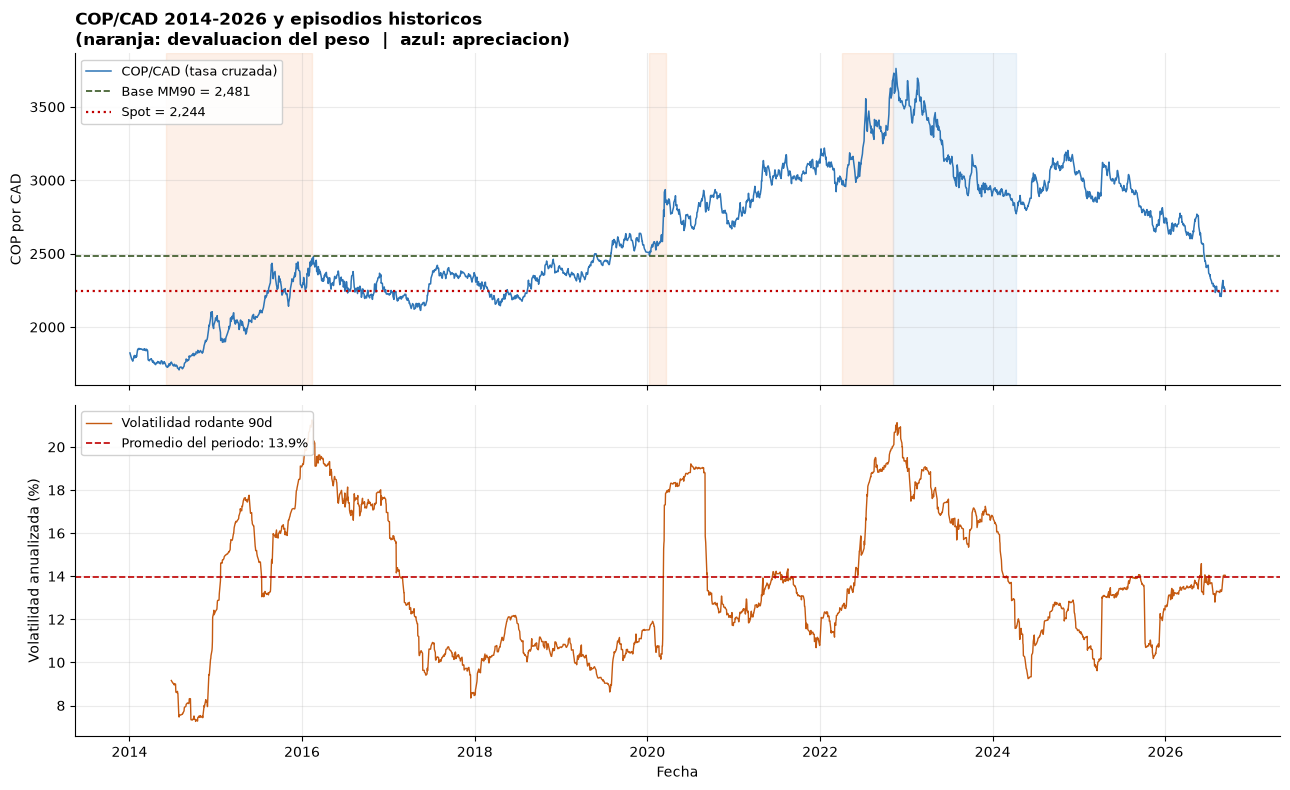

In [18]:
# Figura 4: serie COP/CAD, episodios historicos y volatilidad rodante
fx['vol_rodante_90d'] = fx['retorno_log'].rolling(90).std() * np.sqrt(P['dias_habiles_anio'])

if GRAFICOS:
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    a1.plot(fx.fecha, fx.COP_CAD, color=AZUL, lw=1.1, label='COP/CAD (tasa cruzada)')
    a1.axhline(fx_base, color=VERDE, ls='--', lw=1.2,
               label=f'Base MM{P["ventana_base_dias"]} = {fx_base:,.0f}')
    a1.axhline(fx_spot, color=ROJO, ls=':', lw=1.6, label=f'Spot = {fx_spot:,.0f}')
    for _, e in eps.iterrows():
        fi, ff = pd.Timestamp(e.fecha_inicio), pd.Timestamp(e.fecha_fin)
        if ff >= fx.fecha.min() and fi <= fx.fecha.max():
            a1.axvspan(max(fi, fx.fecha.min()), min(ff, fx.fecha.max()), alpha=.18, zorder=0,
                       color='#F4B183' if e.tipo_movimiento == 'Devaluacion' else '#9DC3E6')
    a1.set_ylabel('COP por CAD')
    a1.legend(loc='upper left', fontsize=9, framealpha=.9)
    a1.set_title(f'COP/CAD {fx.fecha.min():%Y}-{fx.fecha.max():%Y} y episodios historicos'
                 '\n(naranja: devaluacion del peso  |  azul: apreciacion)',
                 fontweight='bold', loc='left')
    a2.plot(fx.fecha, fx.vol_rodante_90d * 100, color=NARANJA, lw=1,
            label='Volatilidad rodante 90d')
    a2.axhline(vol * 100, color=ROJO, ls='--', lw=1.2,
               label=f'Promedio del periodo: {vol * 100:.1f}%')
    a2.set_ylabel('Volatilidad anualizada (%)')
    a2.set_xlabel('Fecha')
    a2.legend(loc='upper left', fontsize=9, framealpha=.9)
    fig.tight_layout()
    guardar(fig, 'figura_04_copcad_volatilidad.png')
    plt.show()

  guardada: figura_05_margenes_escenarios.png  (97 KB)


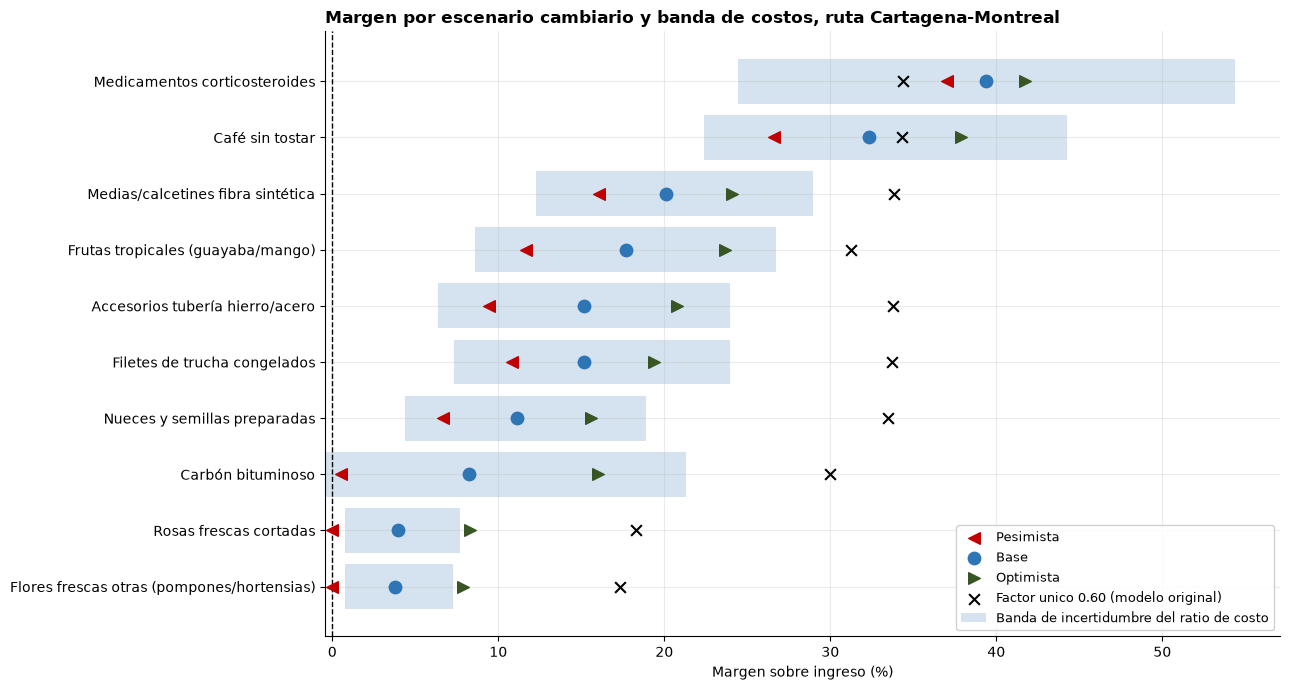

In [19]:
# Figura 5: margen por escenario, con banda de incertidumbre de costos
if GRAFICOS:
    d = (tabla_margenes[tabla_margenes.ruta == 'CTG-Montreal']
         .pivot_table(index='producto', columns='escenario', values='margen_pct'))
    banda = (tabla_margenes[(tabla_margenes.escenario == 'Base') &
                            (tabla_margenes.ruta == 'CTG-Montreal')]
             .set_index('producto')[['margen_pct_min', 'margen_pct_max', 'margen_pct_factor_060']])
    d = d.join(banda).sort_values('Base')

    fig, ax = plt.subplots(figsize=(13, 7))
    ax.barh(d.index, d.margen_pct_max - d.margen_pct_min, left=d.margen_pct_min,
            color=AZUL, alpha=.20, label='Banda de incertidumbre del ratio de costo')
    ax.scatter(d.Pesimista, d.index, color=ROJO, marker='<', s=70, zorder=3, label='Pesimista')
    ax.scatter(d.Base, d.index, color=AZUL, s=80, zorder=4, label='Base')
    ax.scatter(d.Optimista, d.index, color=VERDE, marker='>', s=70, zorder=3, label='Optimista')
    ax.scatter(d.margen_pct_factor_060, d.index, color='black', marker='x', s=60, zorder=5,
               label='Factor unico 0.60 (modelo original)')
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.set_xlabel('Margen sobre ingreso (%)')
    ax.set_title('Margen por escenario cambiario y banda de costos, ruta Cartagena-Montreal',
                 fontweight='bold', loc='left')
    ax.legend(loc='lower right', fontsize=9, framealpha=.9)
    fig.tight_layout()
    guardar(fig, 'figura_05_margenes_escenarios.png')
    plt.show()

  guardada: figura_06_mapa_riesgo_breakeven.png  (98 KB)


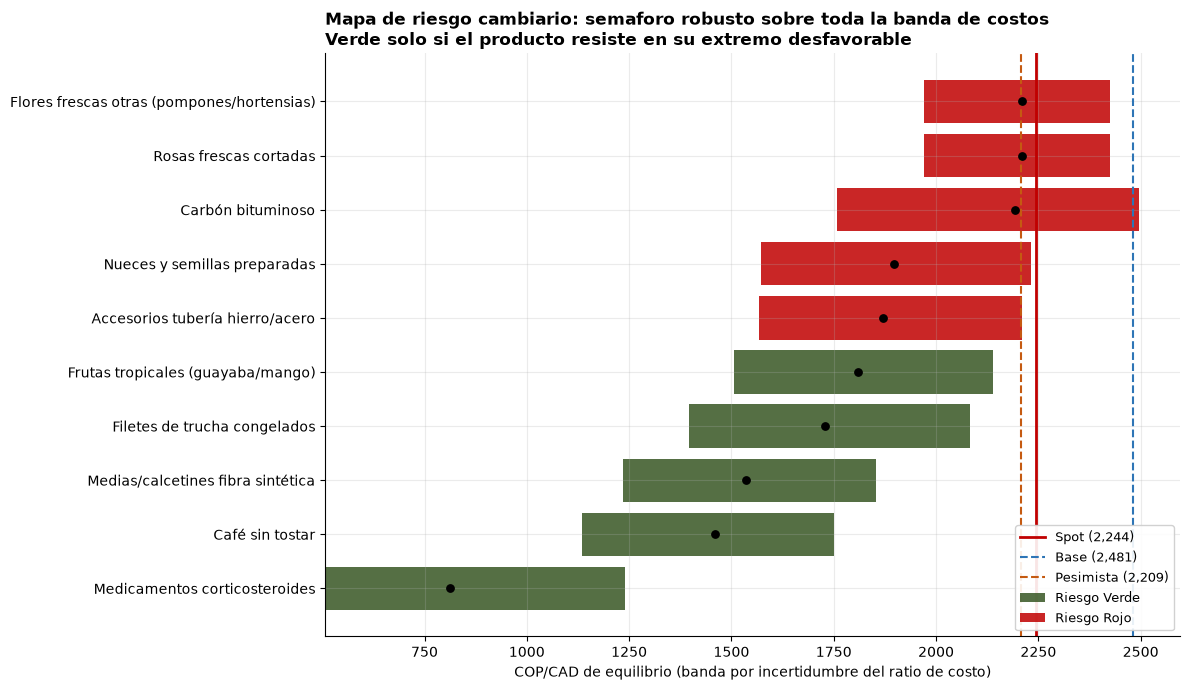

In [20]:
# Figura 6: mapa de riesgo por tipo de cambio de equilibrio, con semaforo robusto
if GRAFICOS:
    b = tabla_be[tabla_be.ruta == 'CTG-Montreal'].sort_values('breakeven')
    finito = np.isfinite(b.breakeven_max)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(b.producto, np.where(finito, b.breakeven_max - b.breakeven_min, 0),
            left=b.breakeven_min, color=[COLOR_RIESGO[x] for x in b.riesgo_robusto], alpha=.85)
    ax.scatter(b.breakeven, b.producto, color='black', zorder=3, s=28)
    lineas = [ax.axvline(fx_spot, color=ROJO, lw=2),
              ax.axvline(fx_base, color=AZUL, ls='--', lw=1.5),
              ax.axvline(ESC['Pesimista'], color=NARANJA, ls='--', lw=1.5)]
    ax.set_xlabel('COP/CAD de equilibrio (banda por incertidumbre del ratio de costo)')
    ax.set_title('Mapa de riesgo cambiario: semaforo robusto sobre toda la banda de costos'
                 '\nVerde solo si el producto resiste en su extremo desfavorable',
                 fontweight='bold', loc='left')
    ax.legend(lineas + [Patch(facecolor=COLOR_RIESGO[n], alpha=.85)
                        for n in b.riesgo_robusto.unique()],
              [f'Spot ({fx_spot:,.0f})', f'Base ({fx_base:,.0f})',
               f'Pesimista ({ESC["Pesimista"]:,.0f})']
              + [f'Riesgo {n}' for n in b.riesgo_robusto.unique()],
              loc='lower right', fontsize=9, framealpha=.9)
    fig.tight_layout()
    guardar(fig, 'figura_06_mapa_riesgo_breakeven.png')
    plt.show()

  guardada: figura_07_stress_testing.png  (90 KB)


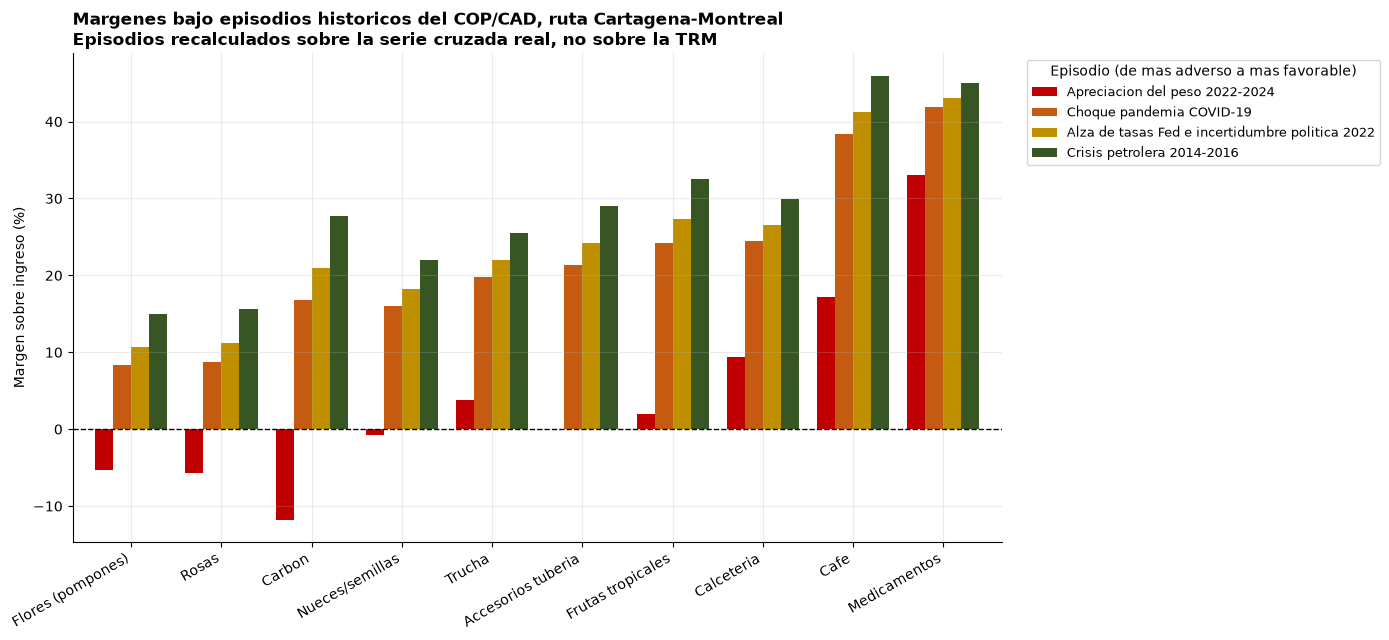

In [21]:
# Figura 7: margenes bajo episodios historicos, recalculados en COP/CAD
if GRAFICOS:
    orden = eps.sort_values('pct_cambio_copcad').nombre_episodio.tolist()
    piv = (tabla_stress[tabla_stress.ruta == 'CTG-Montreal']
           .pivot_table(index='producto', columns='episodio', values='margen_pct')[orden])
    piv = piv.loc[piv.mean(axis=1).sort_values().index]
    piv.index = [CORTO[p] for p in piv.index]

    fig, ax = plt.subplots(figsize=(14, 6.5))
    piv.plot(kind='bar', ax=ax, width=.8,
             color=[ROJO, NARANJA, '#BF8F00', VERDE][:len(orden)])
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_ylabel('Margen sobre ingreso (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for lab in ax.get_xticklabels():
        lab.set_ha('right')
    ax.set_title('Margenes bajo episodios historicos del COP/CAD, ruta Cartagena-Montreal'
                 '\nEpisodios recalculados sobre la serie cruzada real, no sobre la TRM',
                 fontweight='bold', loc='left')
    ax.legend(title='Episodio (de mas adverso a mas favorable)',
              bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    fig.tight_layout()
    guardar(fig, 'figura_07_stress_testing.png')
    plt.show()

  guardada: figura_08_margen_bruto_vs_ajustado.png  (81 KB)


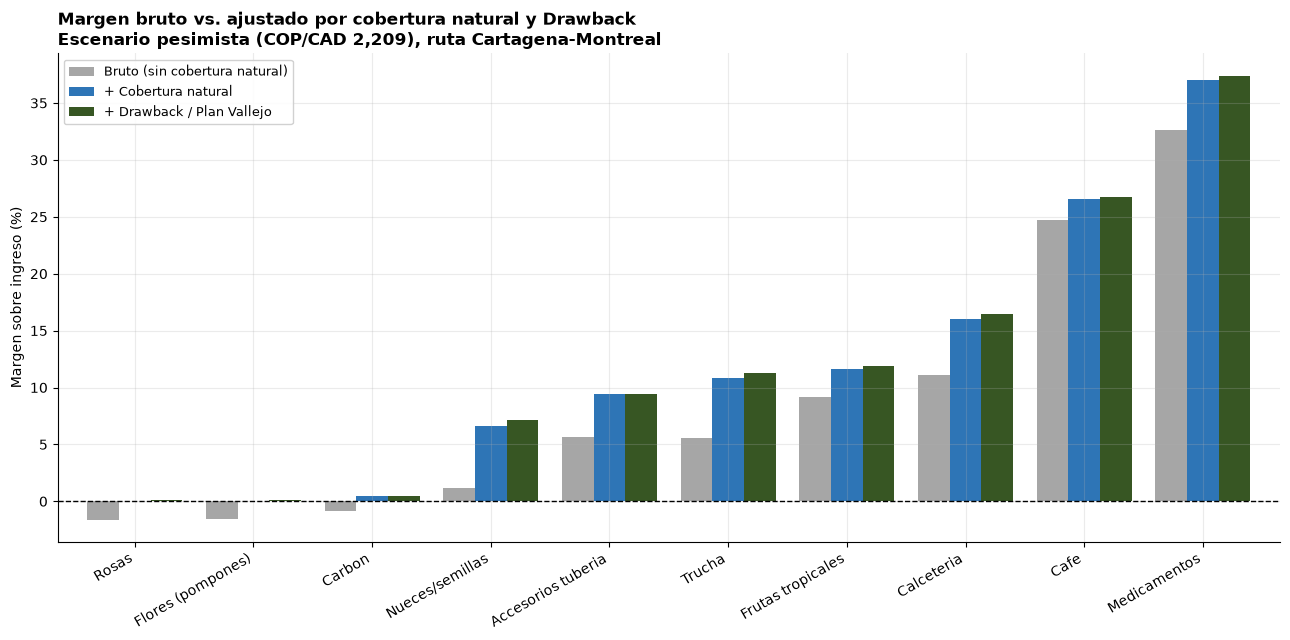

In [22]:
# Figura 8: margen bruto vs. ajustado por cobertura natural y Drawback
# Se dibuja en el escenario PESIMISTA a proposito: en el escenario base la cobertura
# natural tiene efecto exactamente cero por algebra (fx / fx_base = 1), asi que una
# figura en base no mostraria nada de lo que esta figura existe para mostrar.
if GRAFICOS:
    h = (tabla_hedge[(tabla_hedge.ruta == 'CTG-Montreal') &
                     (tabla_hedge.escenario == 'Pesimista')]
         .set_index('producto')[['margen_pct_sin_hedge', 'margen_pct_con_hedge']])
    dwp = (fin[(fin.ruta == 'CTG-Montreal') & (fin.escenario == 'Pesimista')]
           .set_index('producto')[['margen_final_pct']])
    comp = h.join(dwp).sort_values('margen_pct_con_hedge')
    comp.columns = ['Bruto (sin cobertura natural)', '+ Cobertura natural',
                    '+ Drawback / Plan Vallejo']
    comp.index = [CORTO[p] for p in comp.index]

    fig, ax = plt.subplots(figsize=(13, 6.5))
    comp.plot(kind='bar', ax=ax, width=.8, color=['#A6A6A6', AZUL, VERDE])
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_ylabel('Margen sobre ingreso (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for lab in ax.get_xticklabels():
        lab.set_ha('right')
    ax.set_title('Margen bruto vs. ajustado por cobertura natural y Drawback'
                 f'\nEscenario pesimista (COP/CAD {ESC["Pesimista"]:,.0f}), ruta '
                 'Cartagena-Montreal',
                 fontweight='bold', loc='left')
    ax.legend(loc='best', fontsize=9, framealpha=.9)
    fig.tight_layout()
    guardar(fig, 'figura_08_margen_bruto_vs_ajustado.png')
    plt.show()

  guardada: figura_09_efecto_correcciones.png  (78 KB)


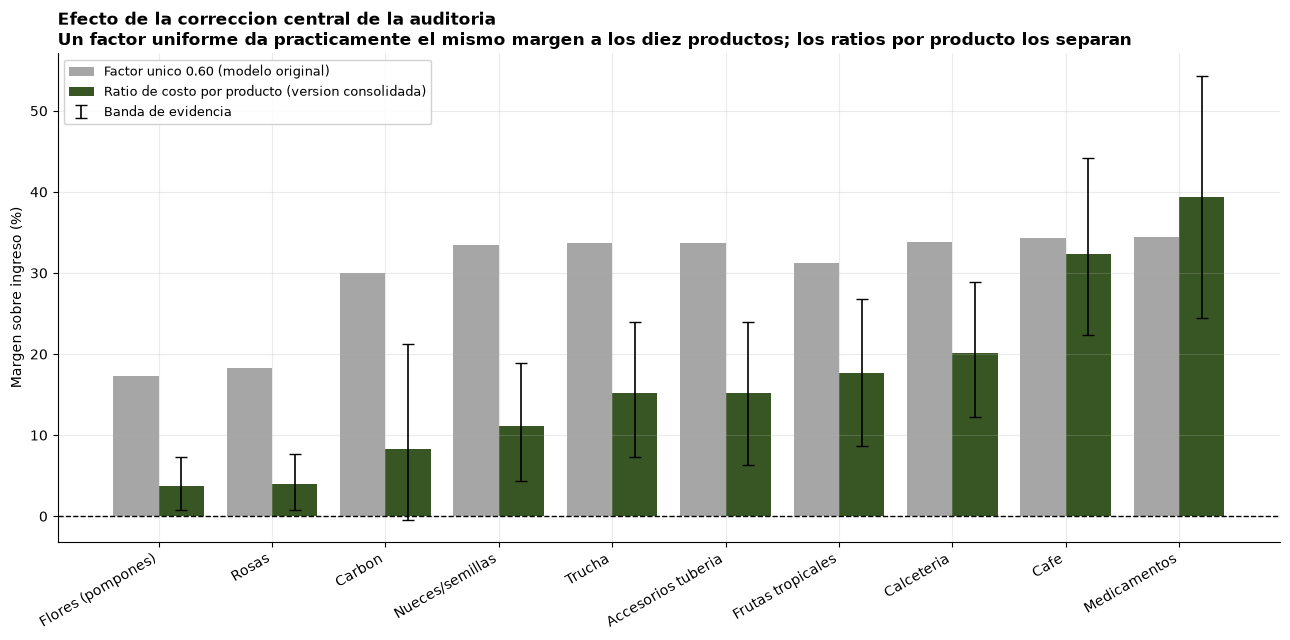

In [23]:
# Figura 9: efecto de reemplazar el factor de costo uniforme por ratios con banda
if GRAFICOS:
    d2 = (tabla_margenes[(tabla_margenes.escenario == 'Base') &
                         (tabla_margenes.ruta == 'CTG-Montreal')]
          .set_index('producto')[['margen_pct_factor_060', 'margen_pct',
                                  'margen_pct_min', 'margen_pct_max']]
          .sort_values('margen_pct'))

    fig, ax = plt.subplots(figsize=(13, 6.5))
    x = np.arange(len(d2))
    ax.bar(x - .2, d2.margen_pct_factor_060, width=.4, color='#A6A6A6',
           label='Factor unico 0.60 (modelo original)')
    ax.bar(x + .2, d2.margen_pct, width=.4, color=VERDE,
           label='Ratio de costo por producto (version consolidada)')
    ax.errorbar(x + .2, d2.margen_pct,
                yerr=[d2.margen_pct - d2.margen_pct_min, d2.margen_pct_max - d2.margen_pct],
                fmt='none', ecolor='black', capsize=4, lw=1.2, label='Banda de evidencia')
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([CORTO[p] for p in d2.index], rotation=30, ha='right')
    ax.set_ylabel('Margen sobre ingreso (%)')
    ax.set_title('Efecto de la correccion central de la auditoria'
                 '\nUn factor uniforme da practicamente el mismo margen a los diez productos; '
                 'los ratios por producto los separan',
                 fontweight='bold', loc='left')
    ax.legend(loc='best', fontsize=9, framealpha=.9)
    fig.tight_layout()
    guardar(fig, 'figura_09_efecto_correcciones.png')
    plt.show()

## 12 · Resumen ejecutivo por producto

Una sola tabla que reúne, para cada producto, todo lo que el modelo puede decir de él y el grado de
evidencia con el que puede decirlo. Es la tabla que alimenta la sección 5 del Working Paper.

In [24]:
_base = (tabla_margenes[(tabla_margenes.escenario == 'Base') &
                        (tabla_margenes.ruta == 'CTG-Montreal')]
         .set_index('codigo_hs'))
_pes = (tabla_margenes[(tabla_margenes.escenario == 'Pesimista') &
                       (tabla_margenes.ruta == 'CTG-Montreal')]
        .set_index('codigo_hs'))
_befin = tabla_be[tabla_be.ruta == 'CTG-Montreal'].set_index('codigo_hs')
_finfin = (fin[(fin.escenario == 'Base') & (fin.ruta == 'CTG-Montreal')]
           .set_index('codigo_hs'))
_vuln = vuln[vuln.ruta == 'CTG-Montreal'].set_index('codigo_hs')
_cap = (cap[(cap.escenario == 'Base') & (cap.ruta == 'CTG-Montreal')].set_index('codigo_hs'))

resumen = pd.DataFrame({
    'producto': _base['producto'],
    'grado_evidencia_costo': _base['grado'],
    'pct_importado': _base['pct_importado'],
    'margen_base_pct': _base['margen_pct'],
    'margen_base_min_pct': _base['margen_pct_min'],
    'margen_base_max_pct': _base['margen_pct_max'],
    'margen_pesimista_pct': _pes['margen_pct'],
    'margen_neto_90d_pct': _cap['margen_neto_90d_pct'],
    'margen_final_con_drawback_pct': _finfin['margen_final_pct'],
    'breakeven_copcad': _befin['breakeven'],
    'colchon_vs_spot_pct': _befin['colchon_vs_spot_pct'],
    'semaforo_robusto': _befin['riesgo_robusto'],
    'exposicion_pp_por_1pct_fx': tabla_elast.set_index('codigo_hs')[
        'delta_margen_pp_por_1pct_fx'],
    'vulnerabilidad_rel_pct': _vuln['vulnerabilidad_rel_pct'],
}).reset_index().sort_values('margen_base_pct', ascending=False)

display(resumen.round(2))
print(f'Semaforo robusto: {resumen.semaforo_robusto.value_counts().to_dict()}')
print(f'Productos con margen base positivo: {(resumen.margen_base_pct > 0).sum()}/10  |  '
      f'que siguen positivos en el escenario pesimista: '
      f'{(resumen.margen_pesimista_pct > 0).sum()}/10')

,codigo_hs,producto,grado_evidencia_costo,pct_importado,margen_base_pct,margen_base_min_pct,margen_base_max_pct,margen_pesimista_pct,margen_neto_90d_pct,margen_final_con_drawback_pct,breakeven_copcad,colchon_vs_spot_pct,semaforo_robusto,exposicion_pp_por_1pct_fx,vulnerabilidad_rel_pct
7,3004.32.00.00,Medicamentos corticosteroides,C,0.65,39.39,24.43,54.35,37.01,36.71,39.79,812.97,63.76,Verde,0.21,29.55
4,0901.11.90.00,Café sin tostar,B,0.25,32.31,22.37,44.24,26.58,29.31,32.48,1460.42,34.91,Verde,0.51,36.03
8,6115.96.00.00,Medias/calcetines fibra sintética,C,0.55,20.11,12.26,28.94,16.04,16.57,20.56,1535.72,31.55,Verde,0.36,57.89
3,0804.50.00.00,Frutas tropicales (guayaba/mango),C,0.30,17.68,8.61,26.74,11.67,14.04,17.91,1809.16,19.36,Verde,0.53,65.85
9,7307.92.00.00,Accesorios tubería hierro/acero,C,0.40,15.16,6.36,23.97,9.42,11.41,15.16,1869.73,16.66,Rojo,0.51,76.75
0,0304.82.00.00,Filetes de trucha congelados,B,0.55,15.16,7.33,23.96,10.84,11.41,15.64,1727.81,22.99,Verde,0.39,76.78
5,2008.19.00.00,Nueces y semillas preparadas,C,0.55,11.16,4.37,18.92,6.66,7.23,11.66,1897.04,15.44,Rojo,0.40,104.34
6,2701.12.00.00,Carbón bituminoso,C,0.15,8.25,-0.43,21.28,0.50,4.19,8.25,2192.81,2.26,Rojo,0.69,141.06
1,0603.11.00.00,Rosas frescas cortadas,B,0.30,3.97,0.79,7.68,-0.01,-0.27,4.13,2209.08,1.54,Rojo,0.34,292.93
2,0603.19.00.00,Flores frescas otras (pompones/hortensias),B,0.30,3.76,0.75,7.27,-0.01,-0.50,3.91,2209.08,1.54,Rojo,0.32,309.46


Semaforo robusto: {'Verde': 5, 'Rojo': 5}
Productos con margen base positivo: 10/10  |  que siguen positivos en el escenario pesimista: 8/10


## 13 · Guardado y verificación de artefactos

Veinte tablas en `outputs/tables/`, seis figuras en `outputs/figures/` y la serie procesada en
`data/processed/`. La verificación es una aserción real: si falta cualquier artefacto o alguno sale
vacío, el cuaderno **falla** en vez de terminar en verde.

In [25]:
salidas = {
    # Trazabilidad de la auditoria
    'tabla_00_registro_correcciones.xlsx': config.OVERRIDES,
    'tabla_00b_grados_de_evidencia.xlsx': config.resumen_evidencia(),
    'tabla_00c_estructura_costos_por_producto.xlsx': config.COSTOS_SECTOR,
    # Bloque A - verificacion manual preliminar
    'tabla_B5_sensibilidad_margenes.xlsx': tabla_B5,
    # Riesgo cambiario
    'tabla_04_indicadores_riesgo.xlsx': pd.DataFrame(
        [{'indicador': 'Volatilidad anualizada', 'valor_pct': vol * 100},
         {'indicador': 'VaR 1d 95%', 'valor_pct': v95 * 100},
         {'indicador': 'VaR 1d 99%', 'valor_pct': v99 * 100},
         {'indicador': 'Expected Shortfall 95%', 'valor_pct': es95 * 100}]
        + [{'indicador': f'VaR {int(x.horizonte_dias)}d 95% (empirico)',
            'valor_pct': x.var_empirico * 100} for x in mh.itertuples()]),
    'tabla_04b_var_multihorizonte.xlsx': mh,
    # Margen, equilibrio y logistica
    'tabla_05_margenes_escenarios.xlsx': tabla_margenes,
    'tabla_06_breakeven.xlsx': tabla_be,
    'tabla_06b_logistica_por_modo.xlsx': fletes,
    'tabla_07_cobertura_natural.xlsx': tabla_hedge,
    # Stress historico
    'tabla_08_episodios_recalculados.xlsx': eps[
        ['nombre_episodio', 'tipo_movimiento', 'fecha_inicio', 'fecha_fin',
         'pct_cambio_trm_original', 'copcad_inicio', 'copcad_fin', 'pct_cambio_copcad',
         'error_pp']],
    'tabla_08b_stress_testing.xlsx': tabla_stress,
    'tabla_08c_margen_al_spot_vigente.xlsx': tabla_hoy,
    # Capital de trabajo y cobertura
    'tabla_09_costo_capital.xlsx': cap,
    'tabla_10_cobertura_costo_beneficio.xlsx': tabla_cob,
    'tabla_10b_vulnerabilidad_relativa.xlsx': vuln,
    # Tributario y sensibilidad
    'tabla_11_margen_final_ajustado.xlsx': fin,
    'tabla_12_sensibilidad_pass_through.xlsx': tabla_sens_pt,
    'tabla_13_sensibilidad_factor_costo.xlsx': tabla_sens_fc,
    'tabla_14_exposicion_cambiaria.xlsx': tabla_elast,
    # Sintesis
    'tabla_15_resumen_ejecutivo.xlsx': resumen,
}
for nombre, df in salidas.items():
    df.to_excel(OUT / 'tables' / nombre, index=False)

FIGURAS = ['figura_04_copcad_volatilidad.png', 'figura_05_margenes_escenarios.png',
           'figura_06_mapa_riesgo_breakeven.png', 'figura_07_stress_testing.png',
           'figura_08_margen_bruto_vs_ajustado.png', 'figura_09_efecto_correcciones.png']

chk = [{'artefacto': f'data/processed/fx_copcad.xlsx', 'tipo': 'serie', 'medida': len(fx),
        'ok': (PROC / 'fx_copcad.xlsx').exists() and len(fx) > 0}]
chk += [{'artefacto': n, 'tipo': 'tabla', 'medida': len(d),
         'ok': (OUT / 'tables' / n).exists() and len(d) > 0} for n, d in salidas.items()]
chk += [{'artefacto': n, 'tipo': 'figura',
         'medida': (round((FIGS / n).stat().st_size / 1024, 1) if (FIGS / n).exists() else 0),
         'ok': (FIGS / n).exists() and (FIGS / n).stat().st_size > 20480} for n in FIGURAS]
checklist = pd.DataFrame(chk)
display(checklist)

falla_datos = checklist[checklist.tipo.isin(['serie', 'tabla'])]
assert falla_datos.ok.all(), \
    f'Faltan artefactos de datos: {falla_datos[~falla_datos.ok].artefacto.tolist()}'
print(f'\nTablas y series: {len(falla_datos)}/{len(falla_datos)} correctas.')

falla_fig = checklist[checklist.tipo == 'figura']
if GRAFICOS:
    assert falla_fig.ok.all(), \
        f'Faltan figuras: {falla_fig[~falla_fig.ok].artefacto.tolist()}'
    print(f'Figuras: {len(falla_fig)}/{len(falla_fig)} correctas.')
else:                                                          # pragma: no cover
    print(f'Figuras: 0/{len(falla_fig)} - OMITIDAS por falta de matplotlib '
          f'({MOTIVO_SIN_GRAFICOS}). Reejecutar el cuaderno al restablecerlo; no requiere '
          f'ningun cambio de codigo.')

print(f'\nSalidas escritas en:\n  {OUT / "tables"}\n  {FIGS}\n  {PROC}')

,artefacto,tipo,medida,ok
0,data/processed/fx_copcad.xlsx,serie,2336.0,True
1,tabla_00_registro_correcciones.xlsx,tabla,2.0,True
2,tabla_00b_grados_de_evidencia.xlsx,tabla,24.0,True
3,tabla_00c_estructura_costos_por_producto.xlsx,tabla,10.0,True
4,tabla_B5_sensibilidad_margenes.xlsx,tabla,30.0,True
5,tabla_04_indicadores_riesgo.xlsx,tabla,7.0,True
6,tabla_04b_var_multihorizonte.xlsx,tabla,3.0,True
7,tabla_05_margenes_escenarios.xlsx,tabla,60.0,True
8,tabla_06_breakeven.xlsx,tabla,20.0,True
9,tabla_06b_logistica_por_modo.xlsx,tabla,20.0,True



Tablas y series: 22/22 correctas.
Figuras: 6/6 correctas.

Salidas escritas en:
  C:\Users\alcal\proyectos personales\mic-cc finanzas\outputs\tables
  C:\Users\alcal\proyectos personales\mic-cc finanzas\outputs\figures
  C:\Users\alcal\proyectos personales\mic-cc finanzas\data\processed


## 14 · Cierre

### Lo que el modelo puede afirmar

1. **La volatilidad del COP/CAD estaba sobreestimada por un problema de emparejamiento de fechas.**
   Alinear la TRM del día *D* con la cotización del Bank of Canada de *D−1* elimina varios cientos
   de puntos básicos de volatilidad anualizada que eran ruido, no riesgo. La cifra impresa en la
   sección 1 es la que debe citarse.

2. **El escenario adverso para estos exportadores es la apreciación del peso, no la devaluación.**
   Es la conclusión opuesta a la narrativa habitual sobre riesgo cambiario en Colombia, y se sigue
   de que estos son generadores de divisas: cobran en CAD y gastan en COP.

3. **El flete internacional no destruye margen bajo FOB.** Restarlo de un ingreso FOB que nunca lo
   incluyó lo cobra dos veces. Ese error, y no la economía del producto, explicaba los márgenes
   catastróficos que la primera versión asignaba al carbón y a las flores.

4. **El forward cambiario paga prima al exportador, no le cuesta.** Con `i_COP > i_CAD` la paridad
   cubierta implica que el forward COP/CAD cotiza sobre el spot. Lo que sí cuesta es el spread del
   NDF. La pregunta de valor esperado y la de reducción de riesgo son distintas y se reportan por
   separado.

5. **El beneficio del Plan Vallejo es el valor financiero del *float* del IVA**, no el 19 % del
   costo importado: las exportaciones son exentas con derecho a devolución, así que ese IVA se
   recupera de todos modos.

6. **La exposición cambiaria y la vulnerabilidad relativa son los dos indicadores que ordenan
   productos con la evidencia disponible.** La cobertura natural y el costo-beneficio del forward
   son casi invariantes al producto por construcción, porque ambos escalan con el ingreso.

### Una advertencia sobre la fecha de ejecución

El modelo descarga la serie cambiaria **en vivo**, así que el spot, la base MM90, los escenarios y
por tanto el semáforo **cambian según el día en que se ejecute**. Eso es deliberado —un modelo de
riesgo calibrado a una fecha congelada de hace dos años no sirve para decidir nada— pero significa
que cualquier cifra citada fuera de este cuaderno debe ir acompañada de su fecha de corte. La celda
de la sección 1 imprime el rango exacto de la serie usada en la corrida.

### Lo que el modelo NO puede afirmar todavía

**Ningún ranking de rentabilidad por producto**, porque siete de los diez ratios de costo son grado
C. Por eso todo resultado por producto aparece como banda y el semáforo exige robustez. Cerrar esa
brecha es **recolección de datos, no programación**: el inventario completo, con la fuente concreta
a la que hay que pedirle cada dato, está en
[`docs/04_datos_pendientes.md`](../docs/04_datos_pendientes.md).

---

*ODEM · Universidad EAN · 2026*